# Analyse des simulations quasi-1D

Ce notebook permet de traiter automatiquement les résultats de simulations quasi-1D et d'en extraire différents paramètres caractéristiques des motifs obtenus.

L'objectif est notamment de quantifier :

- la longueur d'onde caractéristique des motifs à partir de l'autocorrélation ;
- l'espacement moyen entre les motifs ;
- l'épaisseur moyenne des motifs ;
- les régimes dynamiques associés aux différentes conditions de simulation ;
- et finalement de reconstruire les diagrammes de phase à partir de ces différentes mesures.

Le traitement est organisé en plusieurs étapes.

Dans un premier temps, une fonction analyse individuellement chaque simulation et extrait les paramètres nécessaires. Les métadonnées correspondant aux conditions de simulation sont également récupérées directement à partir du nom des fichiers.

Les résultats sont ensuite regroupés pour l'ensemble des simulations contenues dans un dossier et enregistrés sous forme de fichiers .csv. Ces fichiers servent de base aux analyses et aux représentations graphiques réalisées dans les cellules suivantes.

In [ ]:
from scipy.signal import correlate, find_peaks, peak_widths
from scipy.optimize import curve_fit
from pathlib import Path
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import re


def traitement_1D(matfile):

    # Chargement des données du fichier
    data = scipy.io.loadmat(matfile)

    X = data["X"]
    N = data["Nsup"]

    X = X[0, :]
    dx = X[1] - X[0]

    
    # Projection 2D -> 1D
    

    # Rayures parallèles à y
    profile = np.mean(N, axis=0)

    profile0 = profile - np.mean(profile)

    # Autocorrélation
    corr = correlate(
        profile0,
        profile0,
        mode="full"
    )

    corr /= corr.max()

    lags = np.arange(
        -len(profile) + 1,
        len(profile)
    )

    mask = lags >= 0

    corr = corr[mask]
    lags = lags[mask]

    r = lags * dx

    peaks_corr, _ = find_peaks(
        corr,
        prominence=0.02
    )

    peaks_corr = peaks_corr[
        r[peaks_corr] > 2 * dx
    ]

    if len(peaks_corr):

        wavelength = r[peaks_corr[0]]

    else:

        wavelength = np.nan

    corr_length = np.nan

    if len(peaks_corr) >= 3:

        peak_r = r[peaks_corr]
        peak_c = corr[peaks_corr]

        def expo(x, A, xi):
            return A * np.exp(-x / xi)

        try:

            popt, _ = curve_fit(
                expo,
                peak_r,
                peak_c,
                p0=(1, peak_r[-1] / 2)
            )

            A, corr_length = popt

        except RuntimeError:

            corr_length = np.nan

    # Détection des rayures dans le profil N(x)
    stripe_peaks, properties = find_peaks(
        profile,
        prominence=0.05 * np.ptp(profile)
    )

    x_peaks = X[stripe_peaks]

    n_stripes = len(x_peaks)

    Lx = X[-1] - X[0]

    if Lx > 0:
        stripe_density = n_stripes / Lx
    else:
        stripe_density = np.nan

    
    # Espacement entre rayures
    if n_stripes >= 2:

        spacings = np.diff(x_peaks)

        mean_spacing = np.mean(spacings)
        std_spacing = np.std(spacings)

    else:

        spacings = np.array([])

        mean_spacing = np.nan
        std_spacing = np.nan

    
    # Épaisseur des rayures
    # FWHM = largeur à mi-hauteur
    if n_stripes > 0:

        results = peak_widths(
            profile,
            stripe_peaks,
            rel_height=0.5
        )

        stripe_widths = results[0] * dx

        stripe_width = np.mean(stripe_widths)

        stripe_width_std = np.std(stripe_widths)

        # Coordonnées gauche et droite de chaque FWHM
        left_ips = results[2] * dx + X[0]
        right_ips = results[3] * dx + X[0]

    else:

        stripe_widths = np.array([])

        stripe_width = np.nan
        stripe_width_std = np.nan

        left_ips = np.array([])
        right_ips = np.array([])

    
    # Paramètres depuis le nom du fichier
    filename = Path(matfile).stem

    match = re.search(
        r"mu_([0-9.]+)_G_([0-9.]+)_t_([0-9.]+)_cell_([0-9.]+)",
        filename
    )

    if match:

        mu = float(match.group(1))
        G = float(match.group(2))
        t = float(match.group(3))
        cell = float(match.group(4))

    else:

        mu = np.nan
        G = np.nan
        t = np.nan
        cell = np.nan

    
    # FIGURE
    

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(9, 9)
    )

    
    # GRAPHE 1 : N(x)
    ax[0].plot(
        X,
        profile,
        linewidth=1.8,
        label="N(x)"
    )

    
    # Affichage des pics
    if n_stripes > 0:

        # Couleurs correspondant aux épaisseurs
        norm = plt.Normalize(
            vmin=np.min(stripe_widths),
            vmax=np.max(stripe_widths)
        )

        cmap = plt.cm.viridis

        # Points au sommet des pics
        scatter = ax[0].scatter(
            x_peaks,
            profile[stripe_peaks],
            c=stripe_widths,
            cmap=cmap,
            norm=norm,
            s=55,
            zorder=5,
            edgecolor="black",
            linewidth=0.7
        )

        
        # Affichage graphique de la largeur FWHM
        for i in range(n_stripes):

            color = cmap(norm(stripe_widths[i]))

            y_peak = profile[stripe_peaks[i]]

            ax[0].hlines(
                y=y_peak,
                xmin=left_ips[i],
                xmax=right_ips[i],
                color=color,
                linewidth=4,
                alpha=0.9,
                zorder=4
            )

        
        # Colorbar
        cbar = fig.colorbar(
            scatter,
            ax=ax[0],
            pad=0.02
        )

        cbar.set_label(
            "Épaisseur locale FWHM"
        )

        
        # Légende avec valeurs moyennes
        ax[0].plot(
            [],
            [],
            " ",
            label=(
                f"Espacement moyen = "
                f"{mean_spacing:.3f}"
            )
        )

        ax[0].plot(
            [],
            [],
            " ",
            label=(
                f"Épaisseur moyenne = "
                f"{stripe_width:.3f}"
            )
        

        )

        
    
    # Mise en forme N(x)
    ax[0].set_xlabel("X")
    ax[0].set_ylabel("N(x)")

    ax[0].set_title(
        f"Profil 1D - {filename}"
    )

    ax[0].legend(
        loc="best"
    )

    ax[0].grid(
        alpha=0.2
    )

    # GRAPHE 2 : AUTOCORRÉLATION
    ax[1].plot(
        r,
        corr,
        linewidth=2,
        label="Autocorrélation"
    )

    if len(peaks_corr):

        ax[1].plot(
            r[peaks_corr],
            corr[peaks_corr],
            "ro",
            label="Pics autocorrélation"
        )

        ax[1].axvline(
            wavelength,
            color="black",
            linestyle="--",
            label=f"λ = {wavelength:.3f}"
        )

    if (
        len(peaks_corr) >= 3
        and not np.isnan(corr_length)
    ):

        rfit = np.linspace(
            0,
            peak_r[-1],
            300
        )

        ax[1].plot(
            rfit,
            np.exp(-rfit / corr_length),
            "--",
            label=f"ξ = {corr_length:.3f}"
        )

    ax[1].set_xlabel("r")
    ax[1].set_ylabel("C(r)")

    ax[1].set_title(
        "Autocorrélation"
    )

    ax[1].legend()

    ax[1].grid(
        alpha=0.2
    )

    
    # Sauvegarde
    plt.tight_layout()

    outfile = (
        Path(matfile).with_name(
            Path(matfile).stem
            + "_analyse1D.png"
        )
    )

    plt.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        f"\nFigure enregistrée :\n{outfile}"
    )

   
    # Résultats
    return {

        # Metadata
        "t": t,
        "cell": cell,
        "mu": mu,
        "G": G,

        # Autocorrelation
        "lambda": wavelength,
        "xi": corr_length,
        "r": r,
        "corr": corr,

        # Densité
        "density": stripe_density,

        # Espacement
        "esp_moy": mean_spacing,
        "est_std": std_spacing,
        "spacings": spacings,

        # Epaisseur
        "stripe_width": stripe_width,
        "stripe_width_std": stripe_width_std,
        "stripe_widths": stripe_widths,

        # Pics
        "stripe_peaks": stripe_peaks,
        "x_peaks": x_peaks,

        # Profil
        "profile": profile,
        "X": X
    }

# Traitement d'un dossier de simulations

Cette étape permet d'appliquer automatiquement la fonction d'analyse à l'ensemble des simulations contenues dans un dossier.

Pour chaque fichier de simulation :

- le profil quasi-1D est analysé ;
- les paramètres caractéristiques sont calculés ;
- les métadonnées sont récupérées ;
- les résultats sont enregistrés.

Les résultats de toutes les simulations sont ensuite regroupés dans un tableau.

Certains résultats sont également exportés sous forme de fichiers .csv. Ces fichiers constituent la base des analyses réalisées dans les étapes suivantes.

In [8]:
import pandas as pd

# Parcours du dossier

dossier = "t_300000_cell_8000"
folder = Path(f"./Test_cond/{dossier}")

results = []

for matfile in folder.glob("*.mat"):

    print(f"Analyse : {matfile.name}")

    try:

        res = traitement_1D(matfile)

        results.append(res)


    except Exception as e:

        print(
            f"Erreur sur {matfile.name}: {e}"
        )

results_csv = []

for res in results:

    results_csv.append({
        "t": res["t"],
        "cell" : res["cell"],
        "mu": res["mu"],
        "G": res["G"],
        "lambda": res["lambda"],
        "density" : res["density"],
        "esp_moy" : res["esp_moy"],
        "est_std" : res["est_std"],
        "largeur" : res["stripe_width"]
        
    })

df = pd.DataFrame(results_csv)

csvfile = folder / f"{dossier}.csv"

df.to_csv(csvfile, index=False)

print()
print(df)
print()
print(f"Résultats sauvés dans : {csvfile}")


Analyse : mu_0.100_G_0.000_t_300000_cell_8000.mat


C:\Users\lisab\AppData\Local\Temp\ipykernel_13000\3401289635.py:43: RuntimeWarning: invalid value encountered in divide
  corr /= corr.max()



Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.000_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.025_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.025_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.050_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.050_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.075_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.075_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.100_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.100_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.200_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.200_t_300000_cell_8000_analyse1D.png
Analyse : mu_0.100_G_0.300_t_300000_cell_8000.mat

Figure enregistrée :
Test_cond\t_300000_cell_8000\mu_0.100_G_0.300_t_300000_cell_8000_analyse

# Diagramme de phase reconstruit

Cette cellule permet de reconstruire visuellement le diagramme de phase à partir des résultats des simulations.

Pour chaque condition, le profil 1D correspondant est reconstruit et affiché dans une grille.

Les différentes simulations sont ainsi organisées selon leurs paramètres de contrôle afin de reproduire visuellement la structure du diagramme de phase.

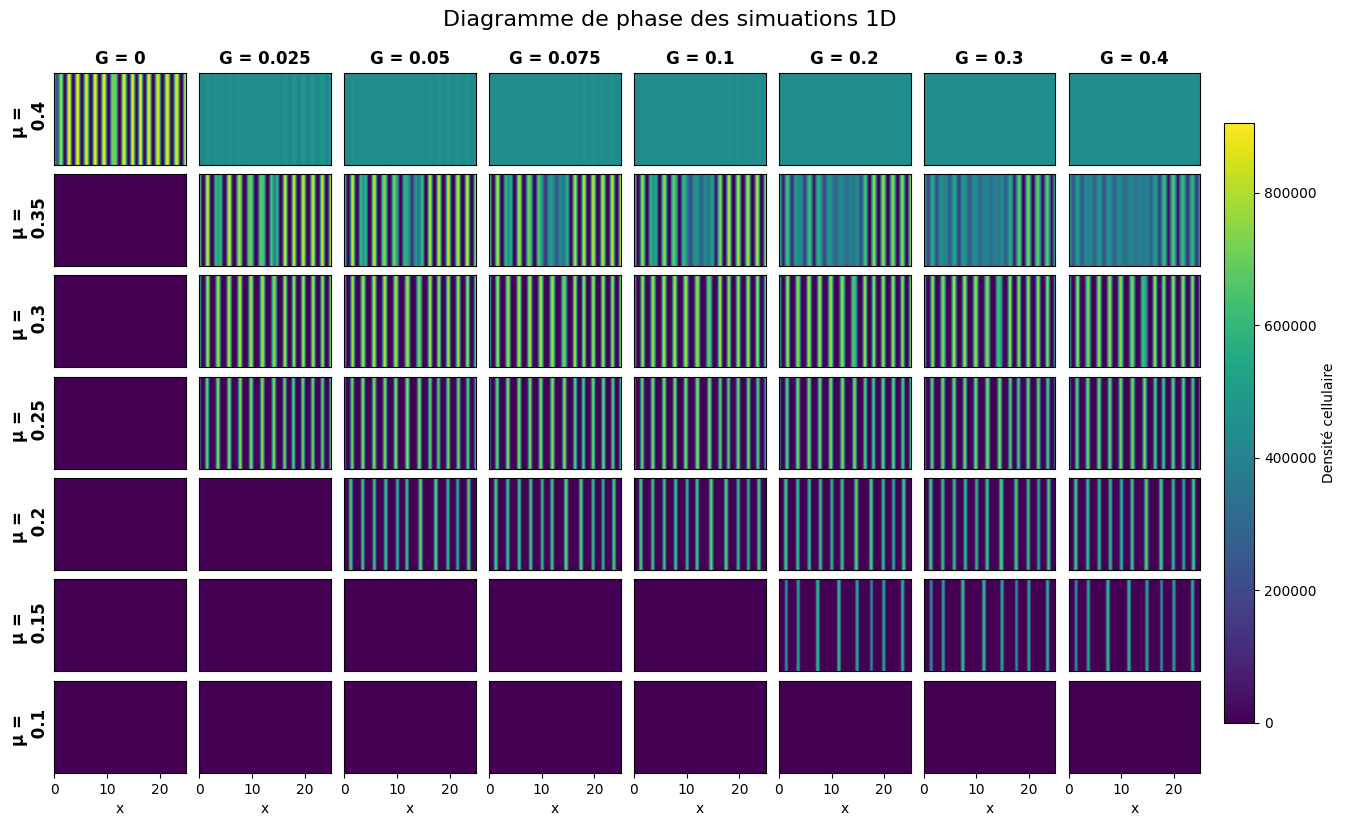

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Valeurs uniques des conditions
mus = np.sort(
    np.unique([
        r["mu"]
        for r in results
        if not np.isnan(r["mu"])
    ])
)

Gs = np.sort(
    np.unique([
        r["G"]
        for r in results
        if not np.isnan(r["G"])
    ])
)


# Nombre de lignes et colonnes
n_mu = len(mus)
n_G = len(Gs)




# Taille d'un panneau
panel_size = 1.5

# Marges supplémentaires pour les labels et la colorbar
left_margin = 1.0
right_margin = 1.0
bottom_margin = 0.8
top_margin = 0.8
colorbar_width = 0.3

# Taille totale de la figure
fig_width = (
    n_G * panel_size
    + left_margin
    + right_margin
    + colorbar_width
)

fig_height = (
    n_mu * panel_size/1.5
    + bottom_margin
    + top_margin
)


# Figure

fig = plt.figure(
    figsize=(fig_width, fig_height)
)
gs = fig.add_gridspec(
    n_mu,
    n_G,
    left=left_margin / fig_width,
    right=(left_margin + n_G * panel_size) / fig_width,
    bottom=bottom_margin / fig_height,
    top=(bottom_margin + n_mu * panel_size/1.5) / fig_height,
    wspace=0.1,
    hspace=0.1
)

axes = np.empty((n_mu, n_G), dtype=object)

for i in range(n_mu):
    for j in range(n_G):
        axes[i, j] = fig.add_subplot(gs[i, j])
'''
fig, axes = plt.subplots(
    n_mu,
    n_G,
    figsize=(3*n_G, 1*n_mu),
    squeeze=True
)'''


# Même échelle de couleur pour toutes les images
all_profiles = np.concatenate([
    r["profile"]
    for r in results
])

vmin = np.nanmin(all_profiles)
vmax = np.nanmax(all_profiles)


# Parcours des conditions
for i, mu in enumerate(mus):

    for j, G in enumerate(Gs):

        ax = axes[n_mu - i -1, j]

        
        # Chercher la simulation correspondant à mu et G
        simu = [
            r for r in results
            if np.isclose(r["mu"], mu)
            and np.isclose(r["G"], G)
        ]

        # Pas de simulation pour cette condition
        if len(simu) == 0:

            ax.axis("off")
            continue

        
        # Si plusieurs simulations existent,
        # on prend la première
        res = simu[0]

        profile = res["profile"]
        X = res["X"]

        
        # Reconstruction d'une image 2D
        

        # Nombre de pixels verticaux uniquement pour
        # visualiser le profil sous forme d'image
        ny = 100

        image = np.tile(
            profile,
            (ny, 1)
        )

        
        # Affichage
        im = ax.imshow(
            image,
            origin="lower",
            aspect="auto",
            extent=[
                X.min(),
                X.max(),
                0,
                1
            ],
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )

        
        # Axes
        ax.set_yticks([])
        

        if i == 0:
            None
            ax.set_xlabel("x")

        else :
            ax.set_xticks([])
            

        # Afficher μ uniquement à gauche
        if j == 0:
            ax.set_ylabel(f"μ = \n {mu:g}", fontsize=12,
                            fontweight="bold")

        else:
            ax.set_yticks([])

       
        # G au-dessus des colonnes
        if i == n_mu -1:
            ax.set_title(
                f"G = {G:g}",
                fontsize=12,
                fontweight="bold"
            )


# Colorbar commune
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.02
)
'''
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=1,
    pad=0.02
)
'''
cbar.set_label(
    "Densité cellulaire"
)


# Mise en forme
fig.suptitle(
    "Diagramme de phase des simuations 1D",
    fontsize=16
)




# Sauvegarde
outfile = folder / "diagramme_conditions_1D.png"

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#  Diagramme de phase traité

Les résultats .csv issus du traitement sont regroupés dans un fichier Excel afin d'associer à chaque condition de simulation le régime observé.

Une colonne supplémentaire doit etre renseignée manuellement afin de classer chaque condition dans l'un des régimes étudiés (Pattern, Mort, Prolifération)

Le diagramme de phase est construit à partir de ce fichier excel. Dans ce diagramme lles conditions effectivement simulées sont représentées par des croix et les differentes régions sont de differentes couleurs. Dans la région Pattern, l'espacement moyen et l'épaiseur moyenne des motifs sont également représentées. La couleur des points permet de représenter la valeur de ces grandeurs et d'observer leur évolution à l'intérieur de la région Pattern.

*À noter* : lorsqu'un profil présente plusieurs pics successifs sans retour complet à zéro entre deux motifs, la condition a été arbitrairement classée dans le régime Prolifération. Cette convention permet de distinguer les profils présentant des motifs clairement individualisés des profils dans lesquels les motifs deviennent fortement fusionnés ce qui impacterait les mesures d'épaisseur et d'espacement.

C:\Users\lisab\AppData\Local\Temp\ipykernel_13000\716806215.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('viridis')


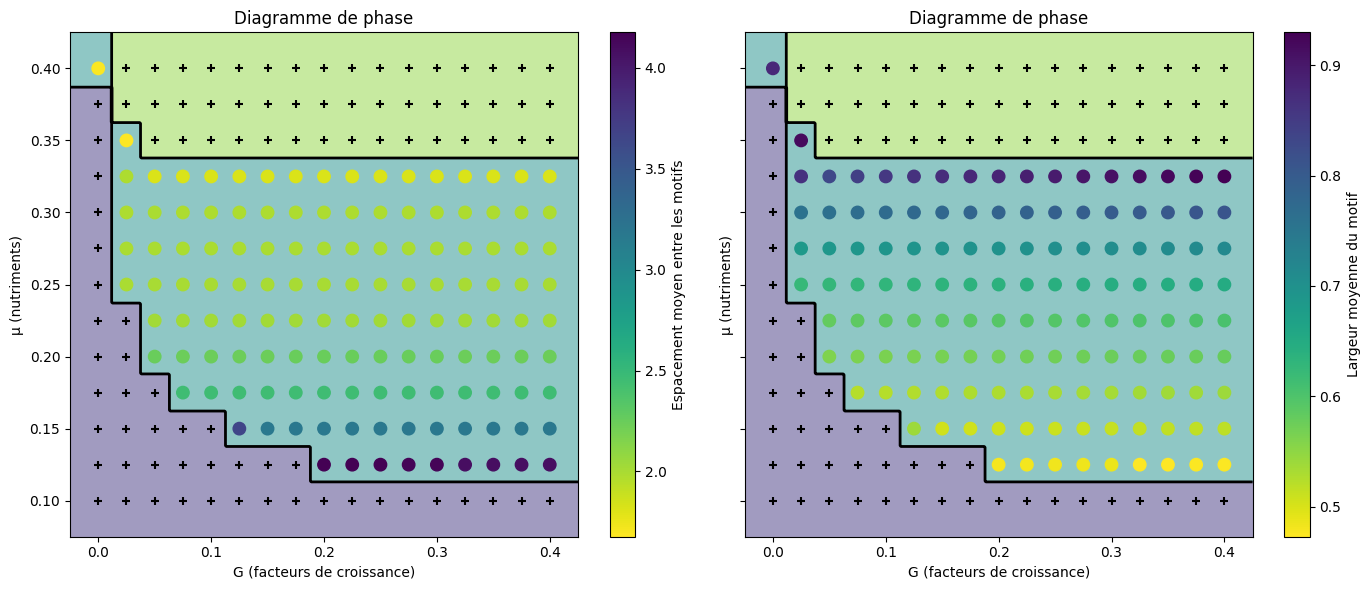

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


# Lecture
df = pd.read_excel("./1D_full_ntRD1/Simufull1D.xlsx")

G = df["Column4"].values
mu = df["Column3"].values
lam1 = df["Column7"].values
epai = df["Column9"].values
cond = df["Column10"].values

# Encodage des phases

phase = np.zeros(len(df))

phase[cond == "Mort"] = 0
phase[cond == "Patterns"] = 1
phase[cond == "Prolifération"] = 2


# Grille régulière
gx = np.linspace(G.min() -0.025, G.max() + 0.025, 300)
gy = np.linspace(mu.min() - 0.025, mu.max() + 0.025, 300)

GX, MU = np.meshgrid(gx, gy)

orig_map=plt.cm.get_cmap('viridis')

# reversing the original colormap using reversed() function
Cmap = orig_map.reversed()


# Interpolation des phases
phase_grid = griddata(
    (G, mu),
    phase,
    (GX, MU),
    method="nearest"
)



# Fond coloré
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,6),
    sharex=True,
    sharey=True
)



ax1.contourf(
    GX,
    MU,
    phase_grid,
    levels=[-0.5,0.5,1.5,2.5],
    alpha=0.5
)

# Frontières
ax1.contour(
    GX,
    MU,
    phase_grid,
    levels=[0.5,1.5],
    colors='k',
    linewidths=2
)


# Région patterns : lambda
mask_pattern = cond == "Patterns"

sc1 = ax1.scatter(
    G[mask_pattern],
    mu[mask_pattern],
    c=lam1[mask_pattern],
    s=80,
    cmap=Cmap,
    #edgecolors='k'
)
fig.colorbar(
    sc1,
    ax=ax1,
    label="Espacement moyen entre les motifs"
)


# Points expérimentaux
mask_mort = cond == "Mort" 
ax1.scatter(
    G[mask_mort],
    mu[mask_mort],
    c='k',
    marker='+',
    s=30
)

mask_Prolif = cond == "Prolifération" 
ax1.scatter(
    G[mask_Prolif],
    mu[mask_Prolif],
    c='k',
    marker='+',
    s=30
)

ax1.set_xlabel("G (facteurs de croissance)")
ax1.set_ylabel("μ (nutriments)")

ax1.set_title("Diagramme de phase")

ax2.contourf(
    GX,
    MU,
    phase_grid,
    levels=[-0.5,0.5,1.5,2.5],
    alpha=0.5
)
ax2.contour(
    GX,
    MU,
    phase_grid,
    levels=[0.5,1.5],
    colors='k',
    linewidths=2
)


# Région patterns : EPAISEUR
mask_pattern = cond == "Patterns"

sc = ax2.scatter(
    G[mask_pattern],
    mu[mask_pattern],
    c=epai[mask_pattern],
    s=80,
    cmap=Cmap,
    #edgecolors='k'
)

fig.colorbar(
    sc,
    ax=ax2,
    label="Largeur moyenne du motif"
)



# Points expérimentaux
mask_mort = cond == "Mort" 
ax2.scatter(
    G[mask_mort],
    mu[mask_mort],
    c='k',
    marker='+',
    s=30
)

mask_Prolif = cond == "Prolifération" 
ax2.scatter(
    G[mask_Prolif],
    mu[mask_Prolif],
    c='k',
    marker='+',
    s=30
)

ax2.set_xlabel("G (facteurs de croissance)")
ax2.set_ylabel("μ (nutriments)")

ax2.set_title("Diagramme de phase")

plt.tight_layout()
plt.show()

# Comparaison de plusieurs diagrammes de phase

Cette cellule permet de comparer plusieurs diagrammes de phase obtenus dans différentes conditions de simulation.

Elle peut notamment être utilisée pour étudier l'évolution du diagramme de phase :

- avec le temps ;
- avec le nombre de cellules ;
- ou avec tout autre paramètre de contrôle étudié.

Les différents diagrammes sont affichés côte à côte afin de faciliter la comparaison de la position et de l'étendue des différents régimes. Les titres et les paramètres affichés doivent être adaptés en fonction de l'étude réalisée.

C:\Users\lisab\AppData\Local\Temp\ipykernel_13000\1965370565.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('viridis')


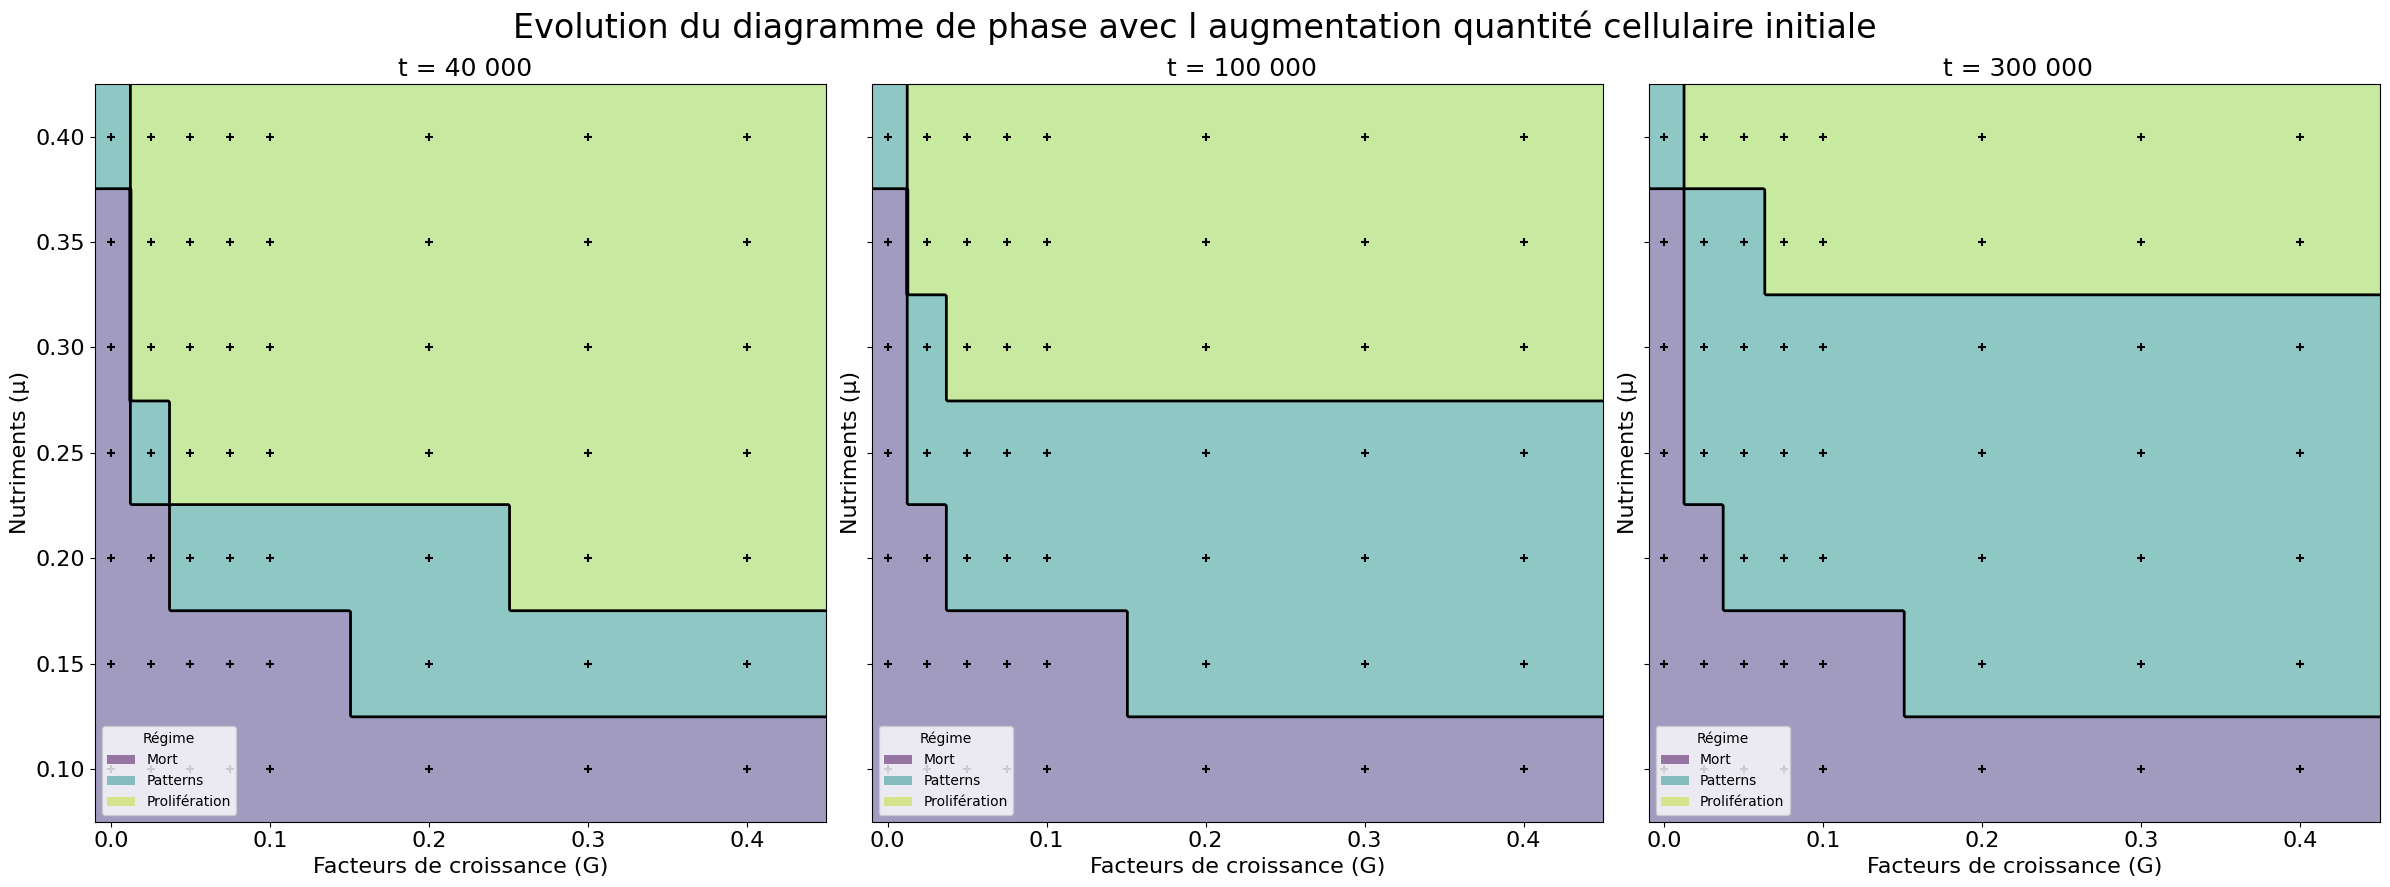

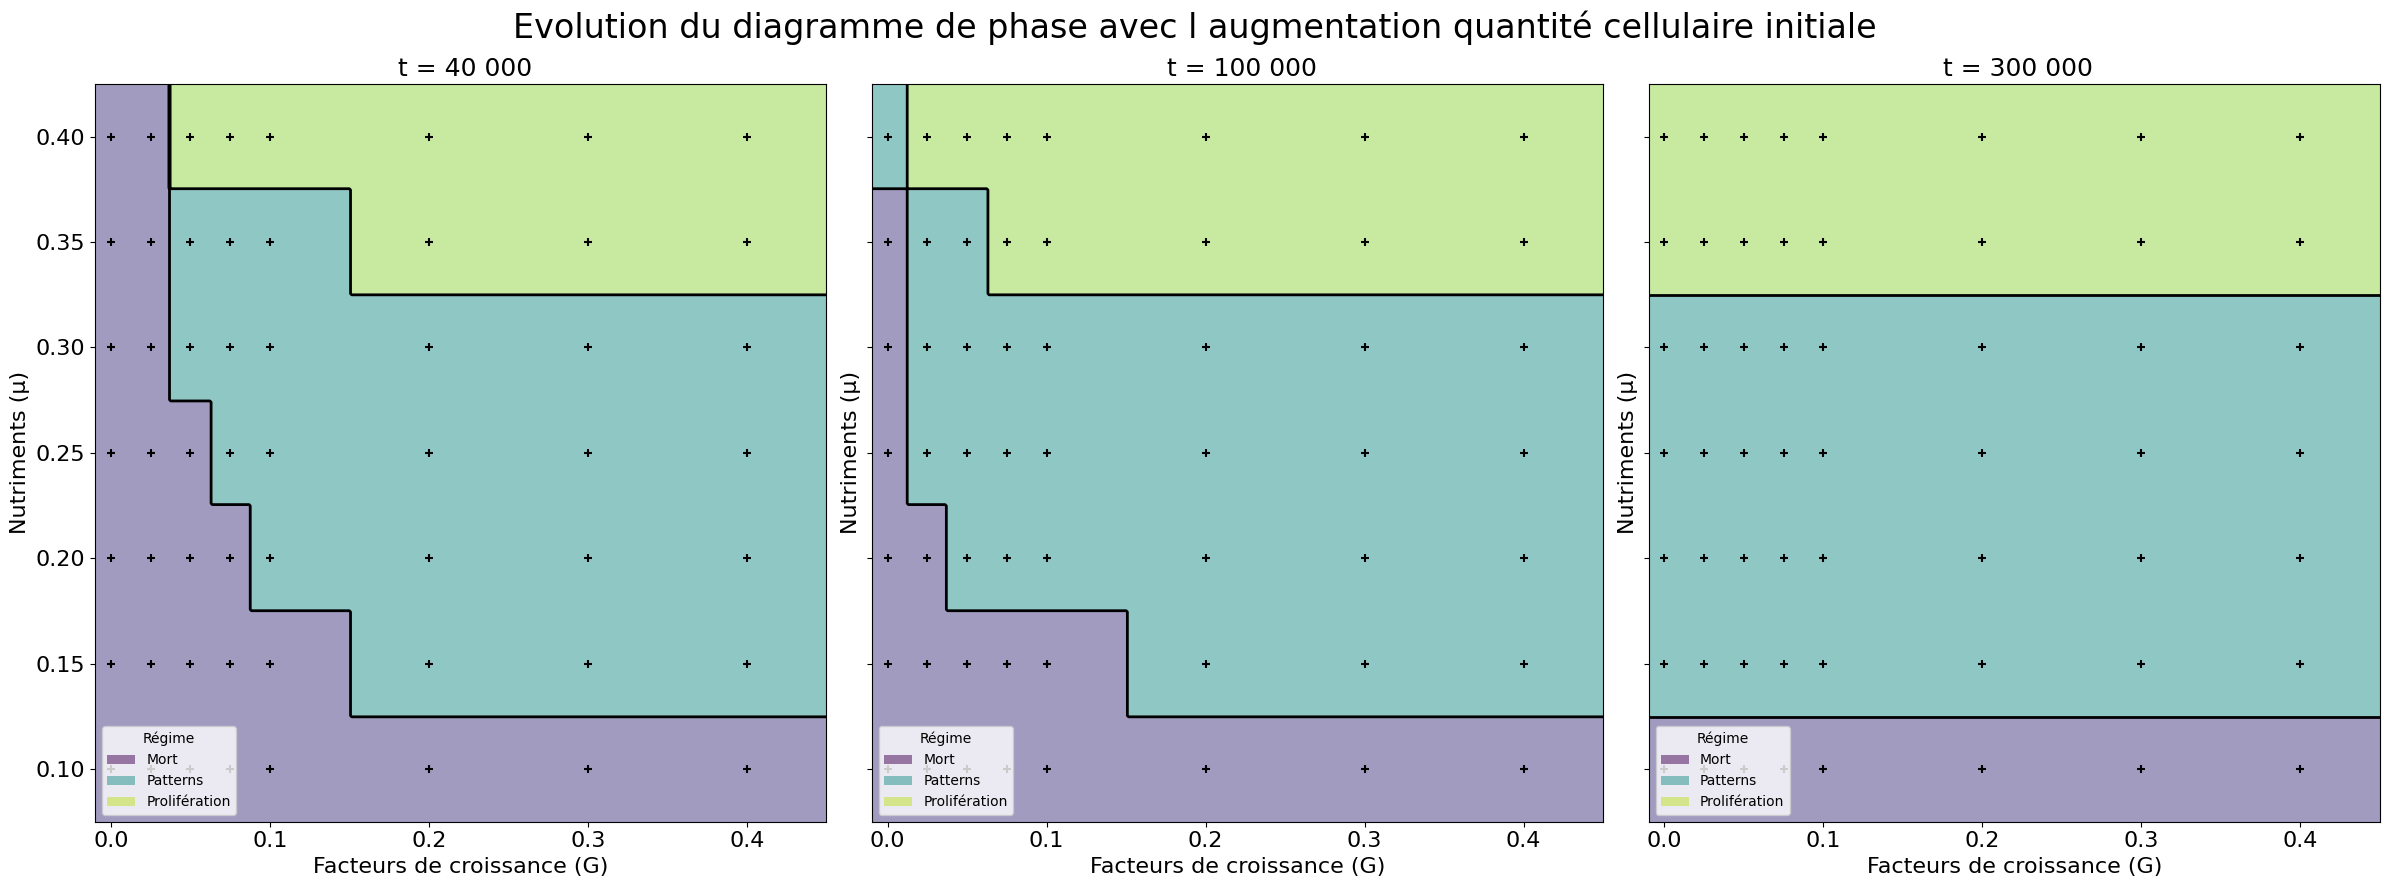

In [12]:
from matplotlib.patches import Patch
excel_file = "./Test_cond/SimuTestcond.xlsx"

sheets = pd.read_excel(
    excel_file,
    sheet_name=None
)

all_pattern_data = []

orig_map=plt.cm.get_cmap('viridis')

# reversing the original colormap using reversed() function
Cmap = orig_map.reversed()


# Groupes de feuilles à comparer
groups = [
    ["t_40000_cells_8000", "t_100000_cells_8000", "t_300000_cell_8000"],
    ["t_300000_cells_2500", "t_300000_cell_8000", "T_30000_cell_25000"]
]

for group in groups:

    fig, axes = plt.subplots(
    1, 3,
    figsize=(24,9),
    sharex=True,
    sharey=True
    )

    for ax, sheet_name in zip(axes, group):

        df = sheets[sheet_name]

        G = df["Column4"].values
        mu = df["Column3"].values
        cond = df["Column10"].values

        
        # Encodage des phases

        phase = np.zeros(len(df))

        phase[cond == "Mort"] = 0
        phase[cond == "Patterns"] = 1
        phase[cond == "Prolifération"] = 2

        
        # Grille
        gx = np.linspace(G.min()-0.01, G.max()+0.05, 300)
        gy = np.linspace(mu.min()-0.025, mu.max()+0.025, 300)

        GX, MU = np.meshgrid(gx, gy)

        phase_grid = griddata(
            (G, mu),
            phase,
            (GX, MU),
            method="nearest"
        )

        
        # Fond
        ax.contourf(
            GX,
            MU,
            phase_grid,
            levels=[-0.5,0.5,1.5,2.5],
            alpha=0.5
            
            
        )

        
        # Frontières
        ax.contour(
            GX,
            MU,
            phase_grid,
            levels=[0.5,1.5],
            colors="k",
            linewidths=2
        )

        
        # Mort
        mask = cond == "Patterns"
    
        ax.scatter(
            G[mask],
            mu[mask],
            marker="+",
            c="k",
            s=30
        )
        
        mask = cond == "Mort"

        ax.scatter(
            G[mask],
            mu[mask],
            marker="+",
            c="k",
            s=30
        )

        # Prolifération
        mask = cond == "Prolifération"

        ax.scatter(
            G[mask],
            mu[mask],
            marker="+",
            c="k",
            s=30
        )
        ax.set_xlabel("Facteurs de croissance (G)", fontsize = 16)
        ax.set_ylabel("Nutriments (μ)", fontsize = 16)
        ax.tick_params(axis='both', labelsize=16)

        cmap = plt.cm.viridis
        norm = plt.Normalize(vmin=0, vmax=2)
    
        legend_elements = [
            Patch(
                facecolor=cmap(norm(0)), alpha=0.5,
                label="Mort"
            ),
            Patch(
                facecolor=cmap(norm(1)), alpha=0.5,
                label="Patterns"
            ),
            Patch(
                facecolor=cmap(norm(1.8)), alpha=0.5,
                label="Prolifération"
            )
        ]
    
        ax.legend(
        handles=legend_elements,
        title="Régime",
        loc="lower left"
        )

    axes[0].set_title(" t = 40 000", fontsize = 18)
    axes[1].set_title(" t = 100 000", fontsize = 18)
    axes[2].set_title(" t = 300 000", fontsize = 18)

    '''
    axes[0].set_title(r"$n_{0}$ = 2 500", fontsize = 18)
    axes[1].set_title(r"$n_{0}$ = 8 000", fontsize = 18)
    axes[2].set_title(r"$n_{0}$ = 25 000", fontsize = 18)'''

    fig.suptitle('Evolution du diagramme de phase avec l augmentation quantité cellulaire initiale', fontsize=24)
    plt.tight_layout()
    
plt.show()

# Étude de la variabilité liée à la disposition initiale

Afin d'étudier l'influence de la configuration initiale des cellules, 20 simulations indépendantes sont réalisées avec des répartitions cellulaires aléatoires.

Les résultats obtenus pour ces différentes simulations sont regroupés dans un fichier Excel. Chaque feuille du fichier correspond à une simulation indépendante.

Pour chaque condition de simulation identifiée comme appartenant au régime Pattern, les grandeurs d'espacement et d'épaisseur sont extraites.
Les résultats des différentes simulations sont ensuite comparés afin de quantifier la variabilité induite par la disposition initiale des cellules.

Pour chaque condition de simulation, les valeurs obtenues dans les différentes réalisations sont représentées sous forme de nuage de points. Chaque point correspond à une simulation indépendante. La moyenne et l'écart-type des différentes réalisations sont calculés.

C:\Users\lisab\AppData\Local\Temp\ipykernel_15064\2828583901.py:93: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(


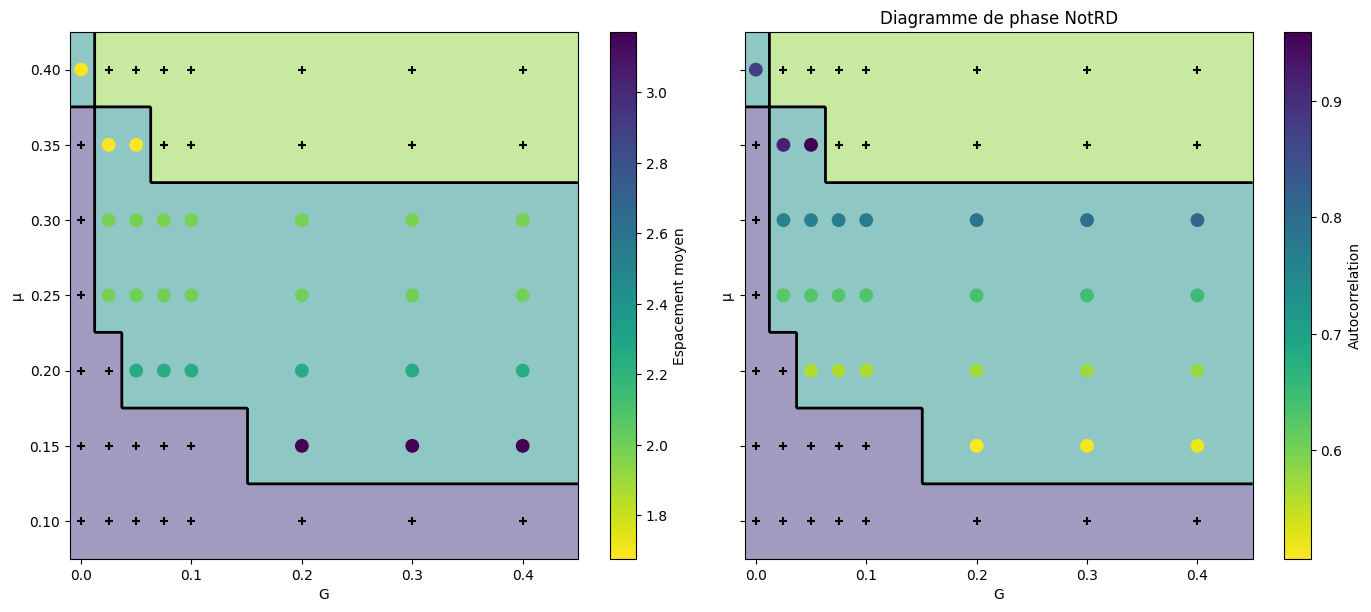

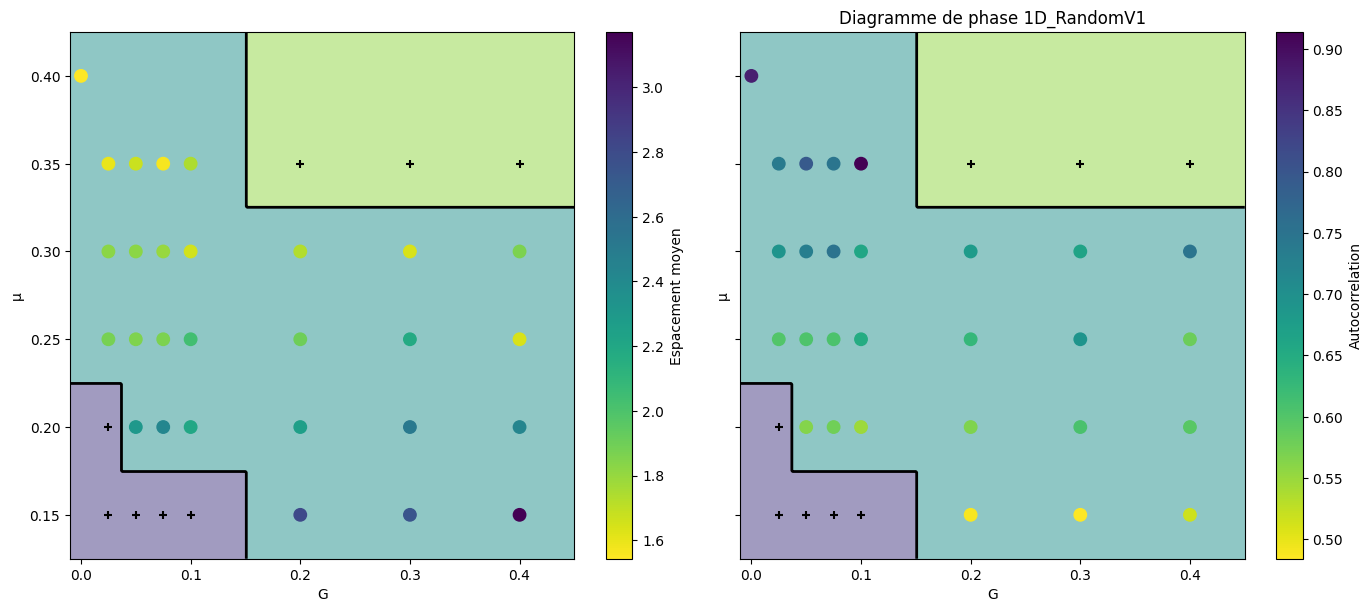

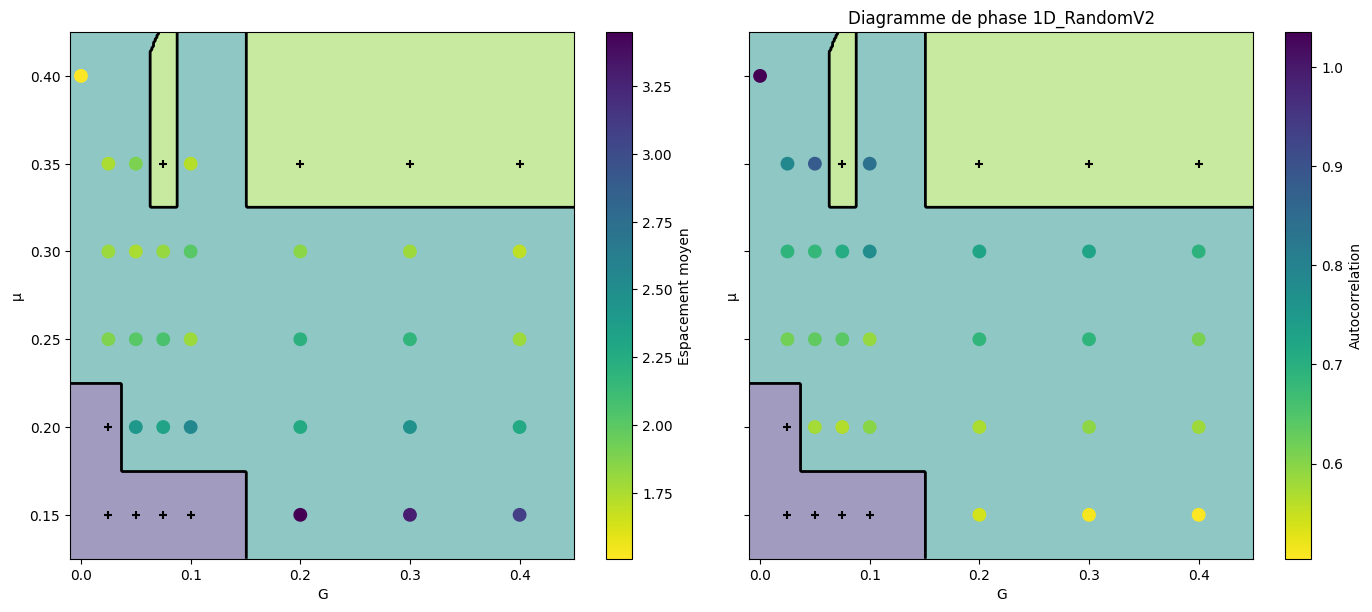

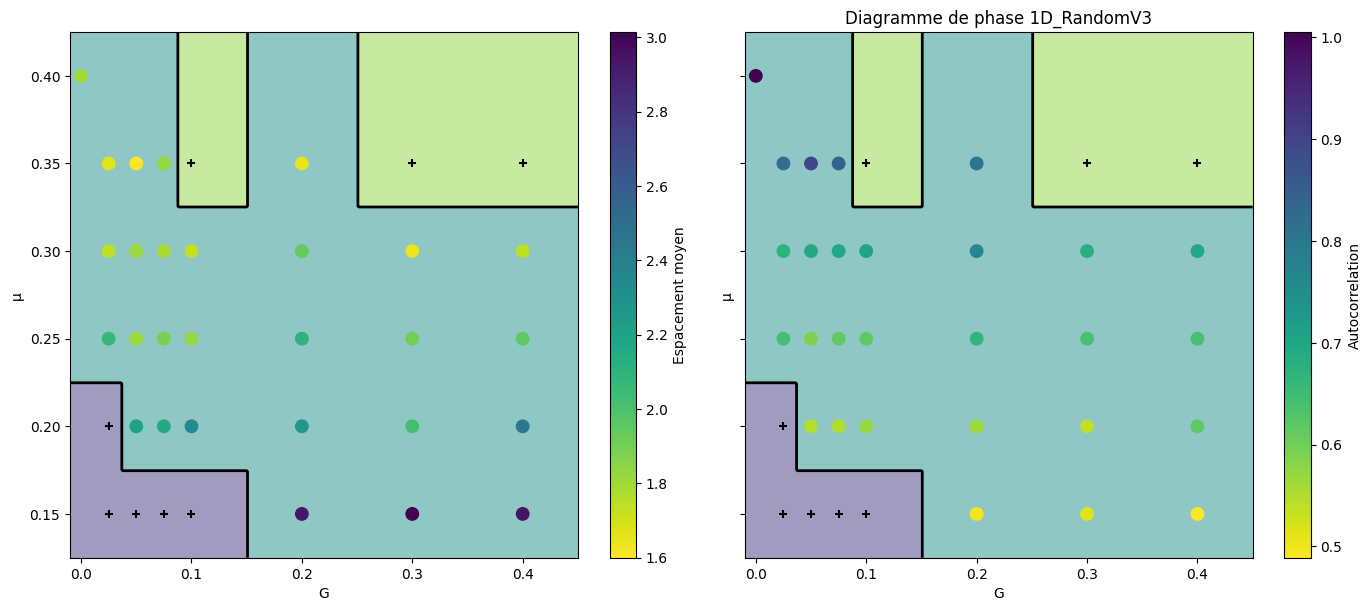

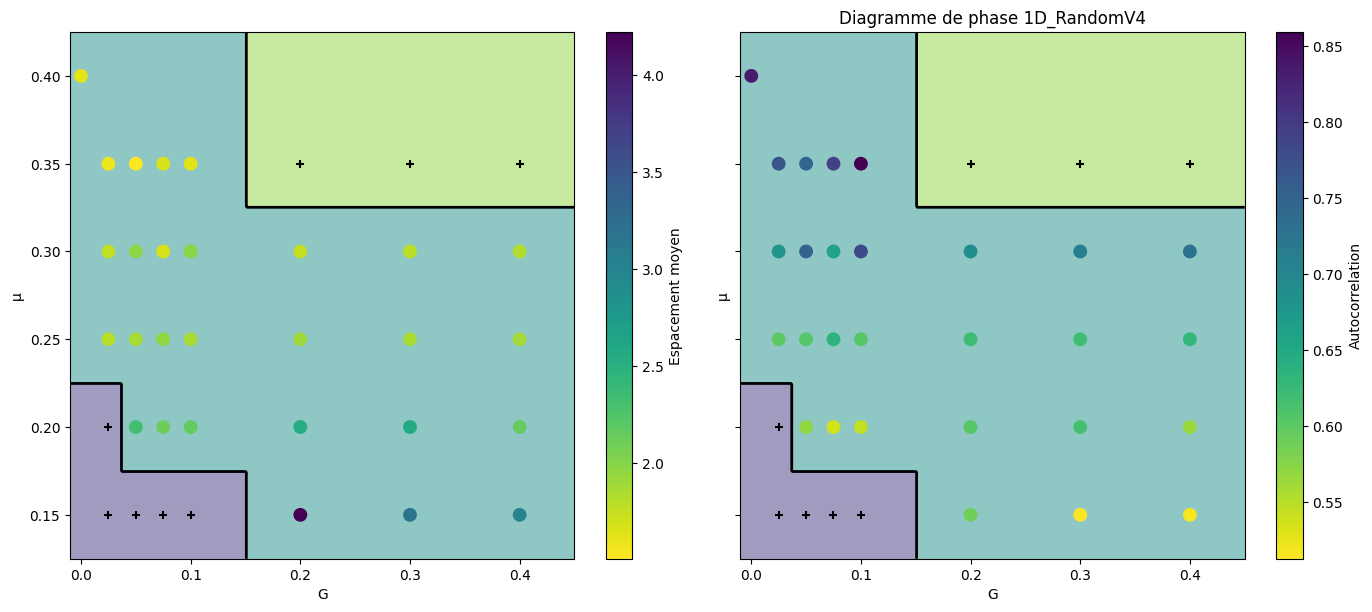

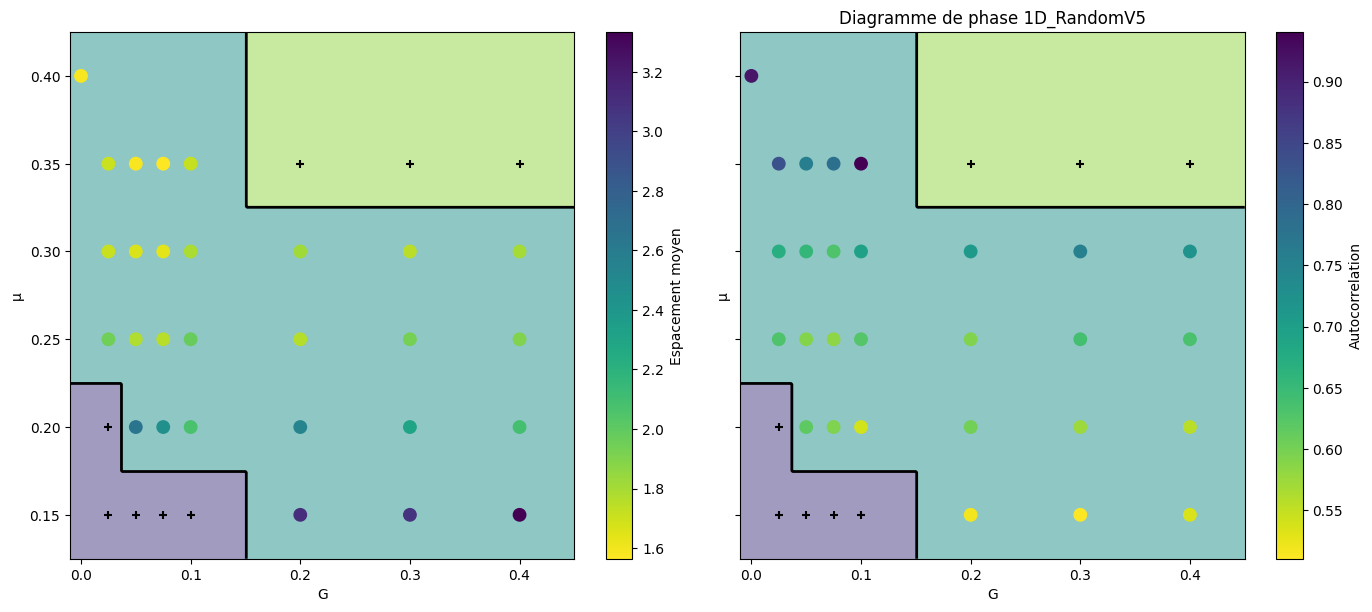

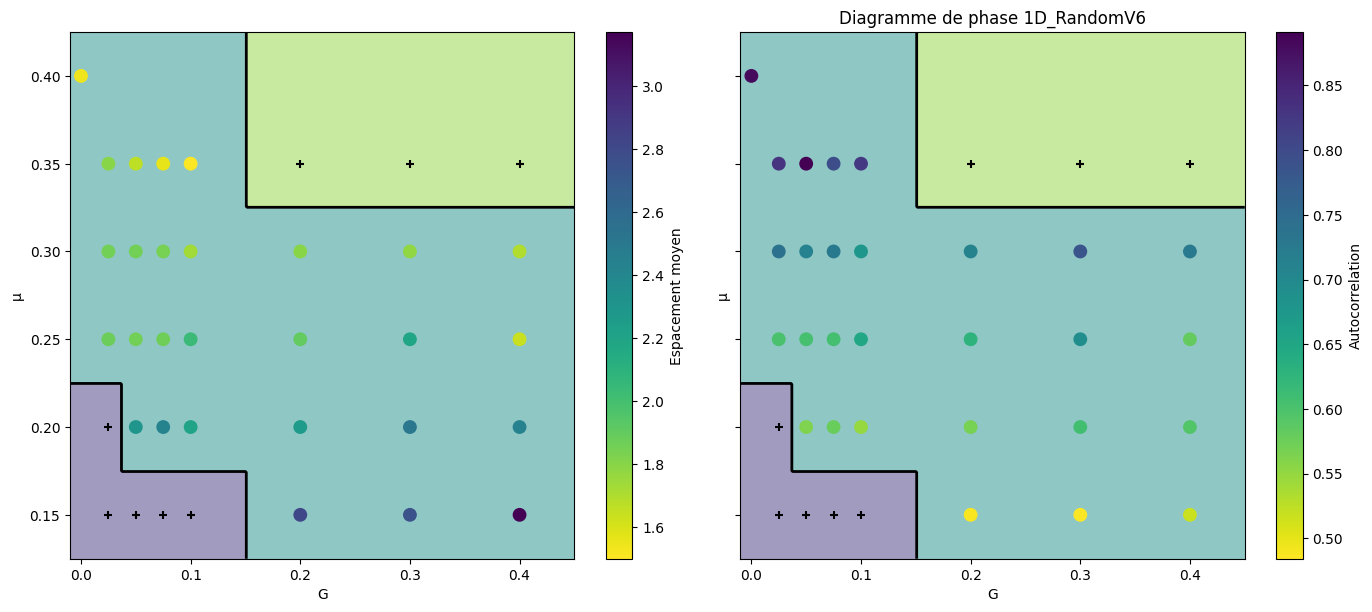

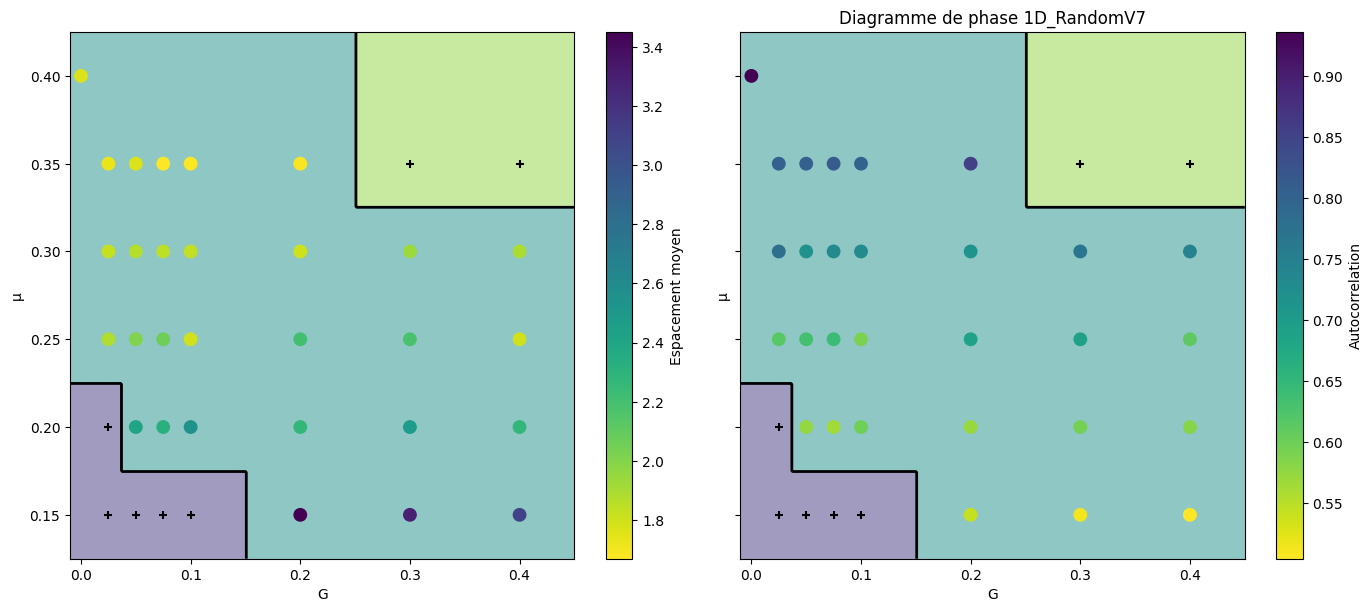

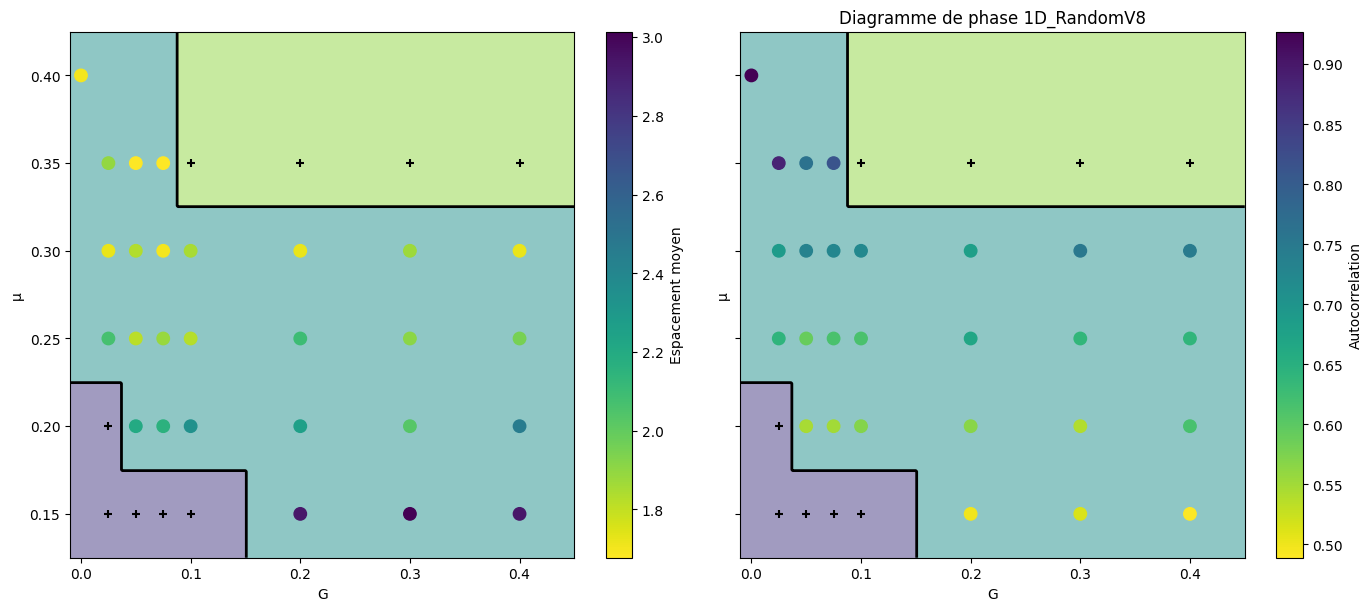

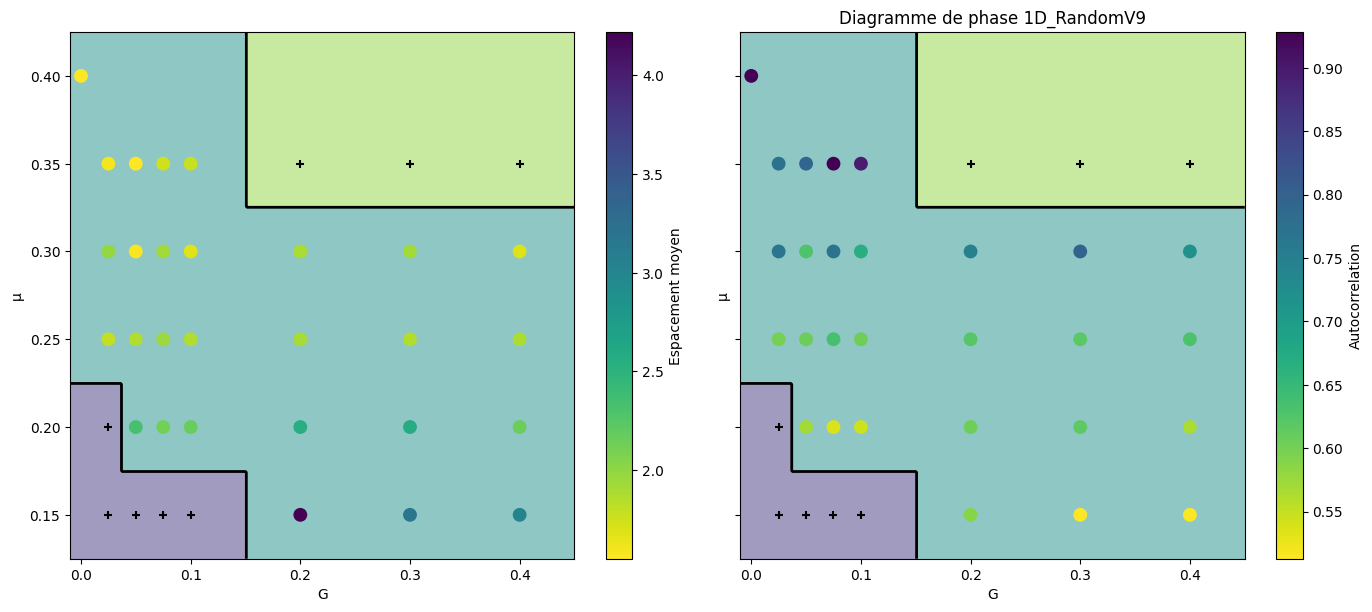

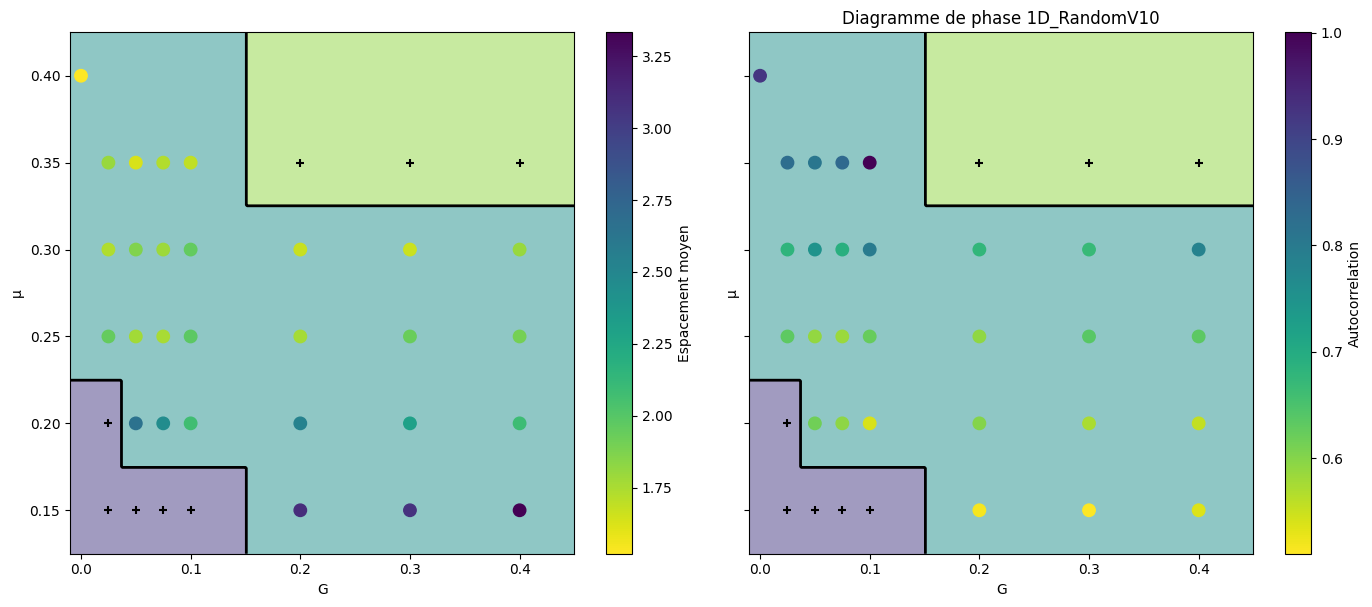

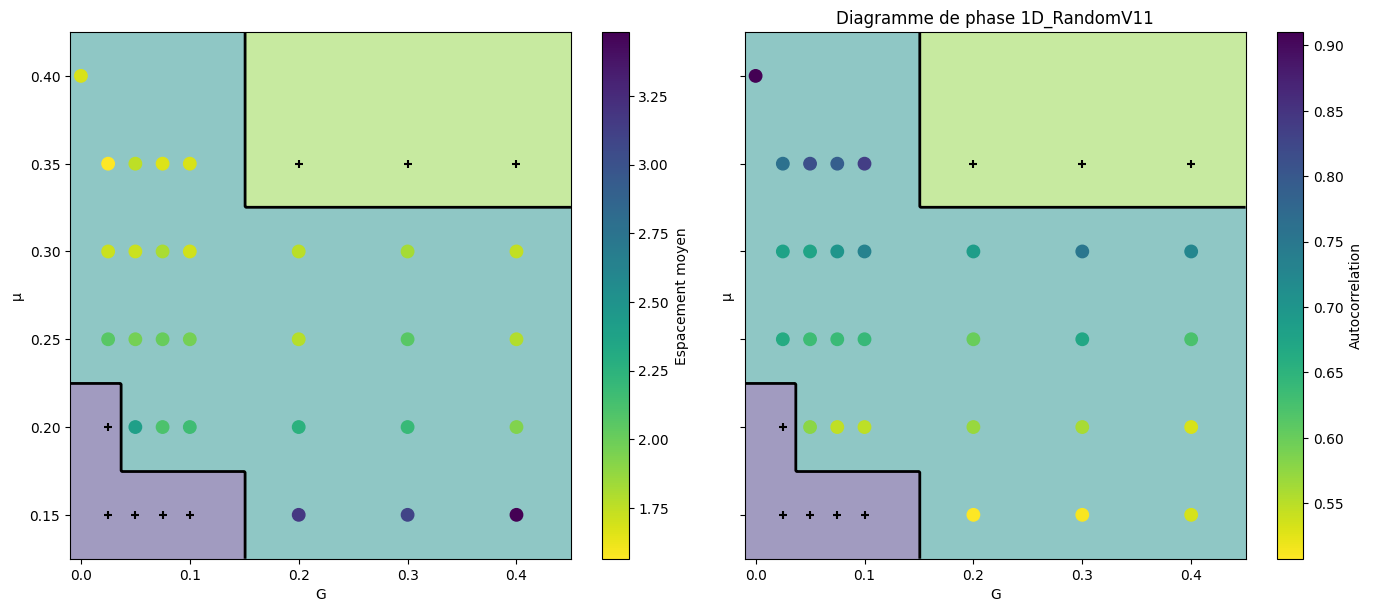

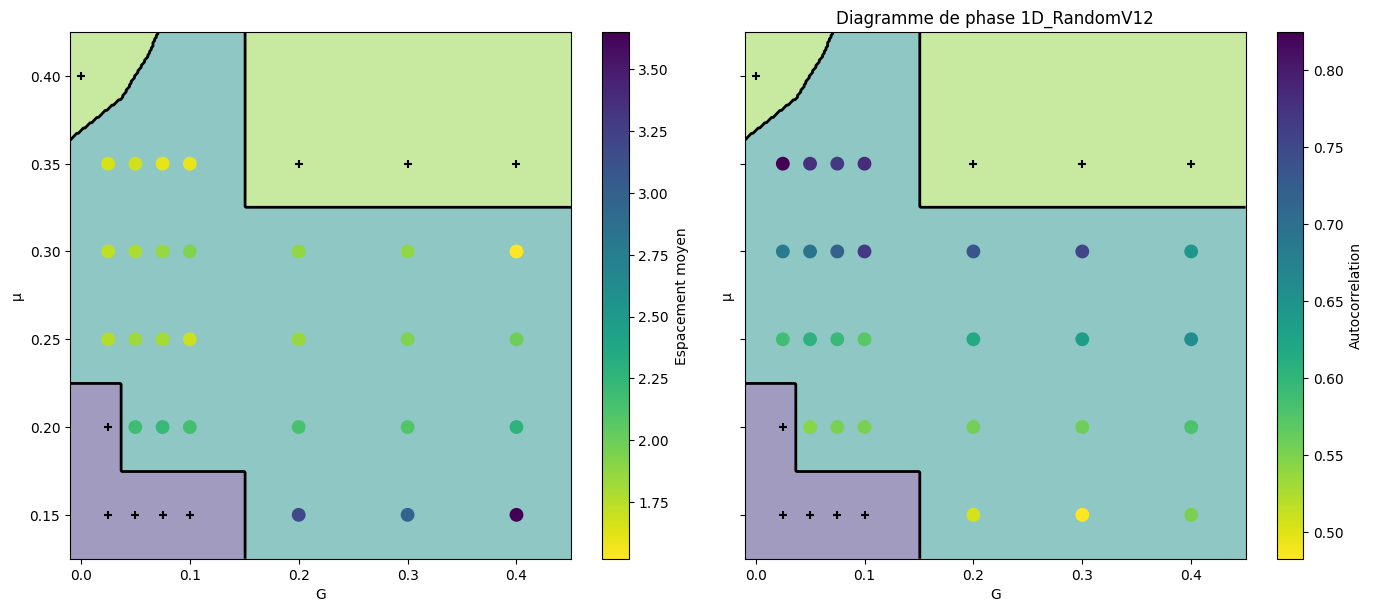

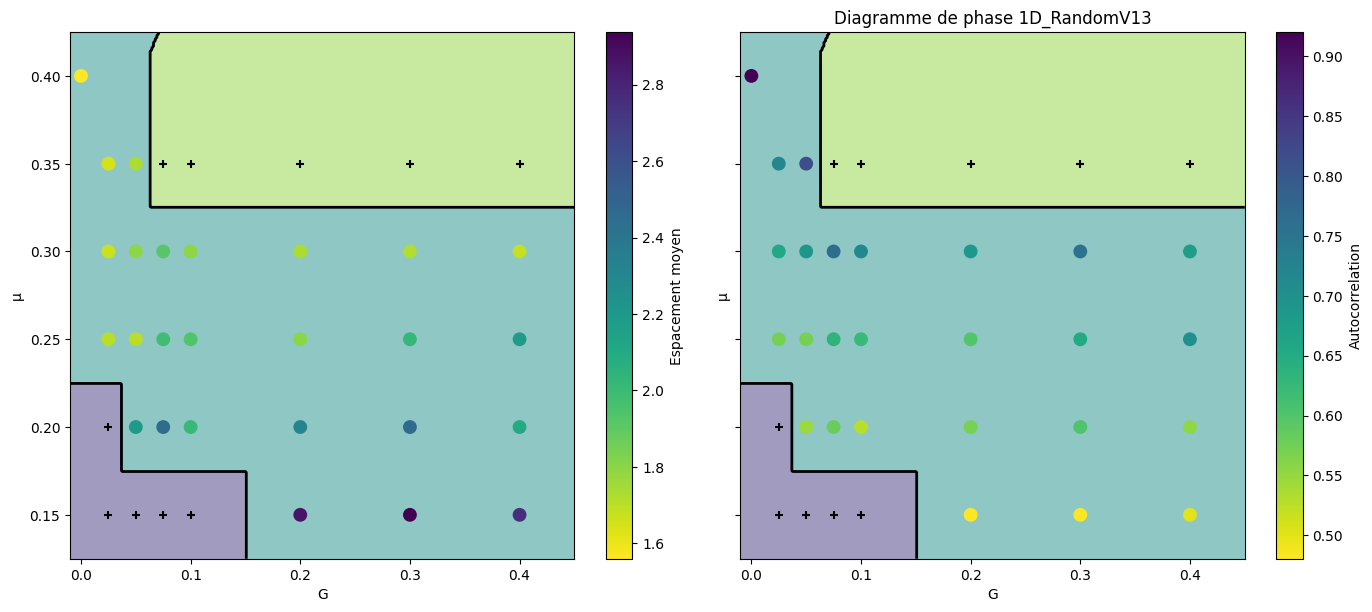

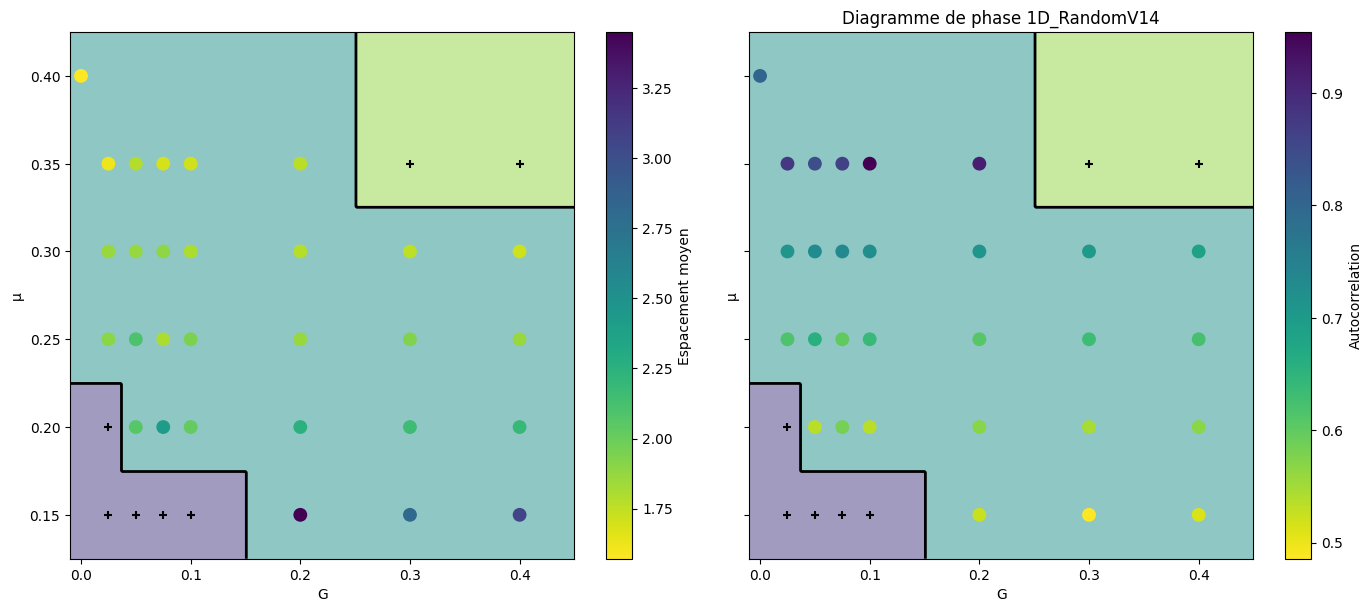

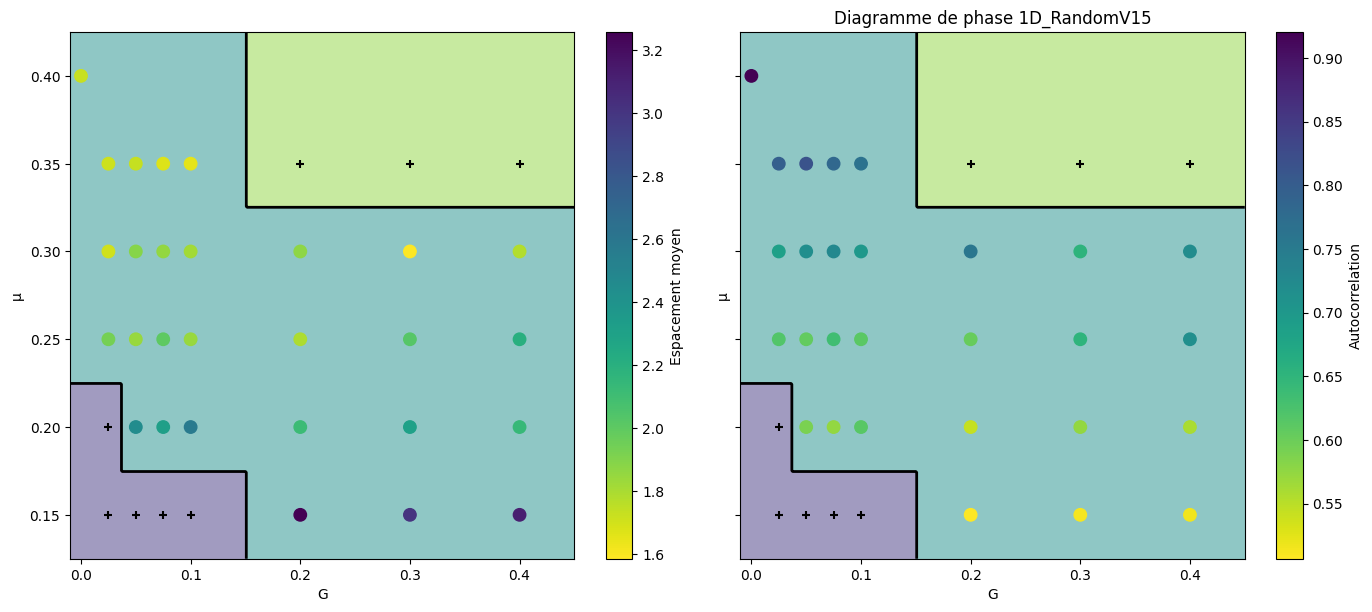

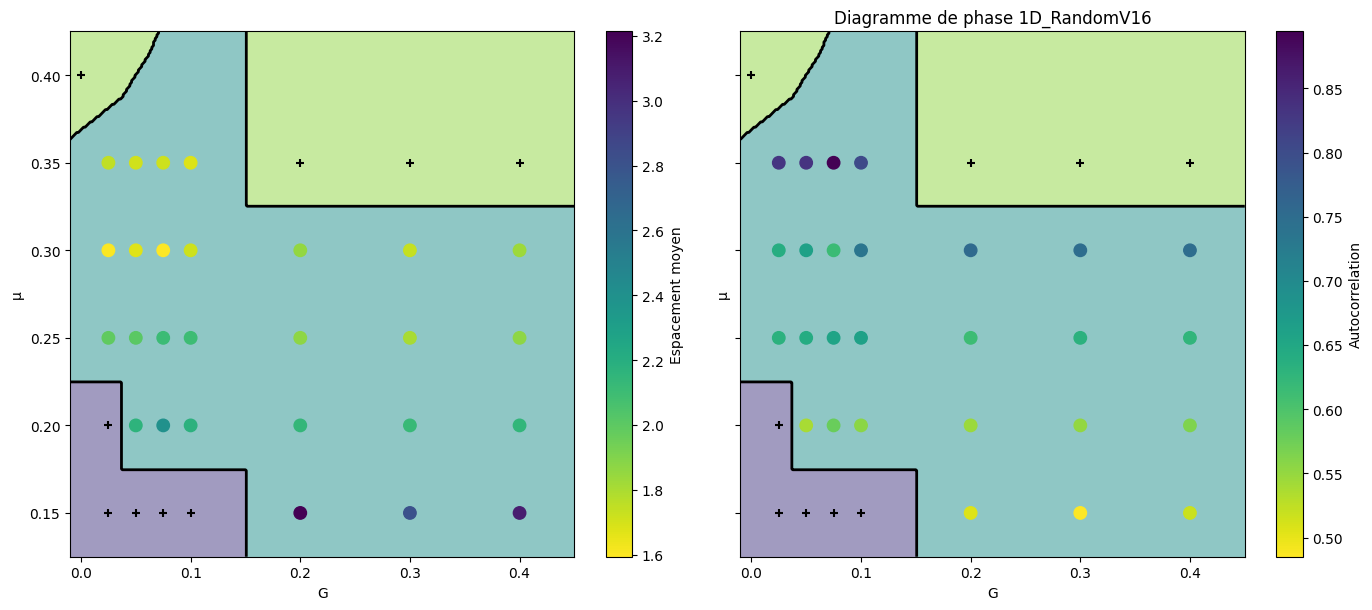

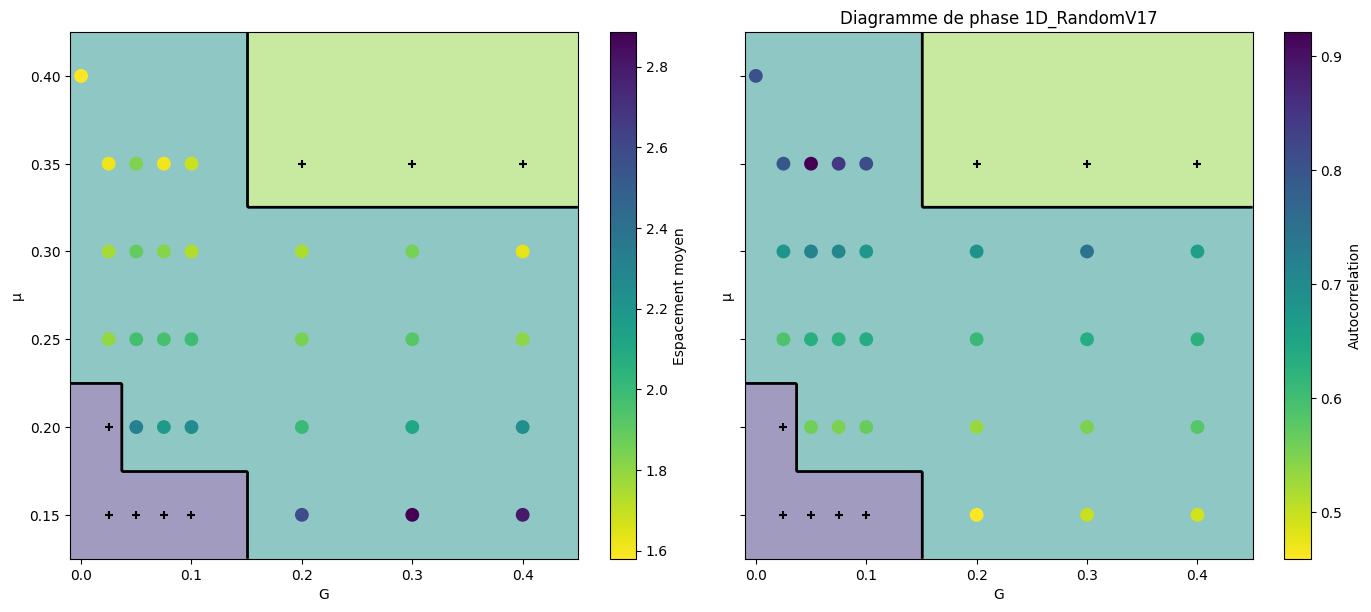

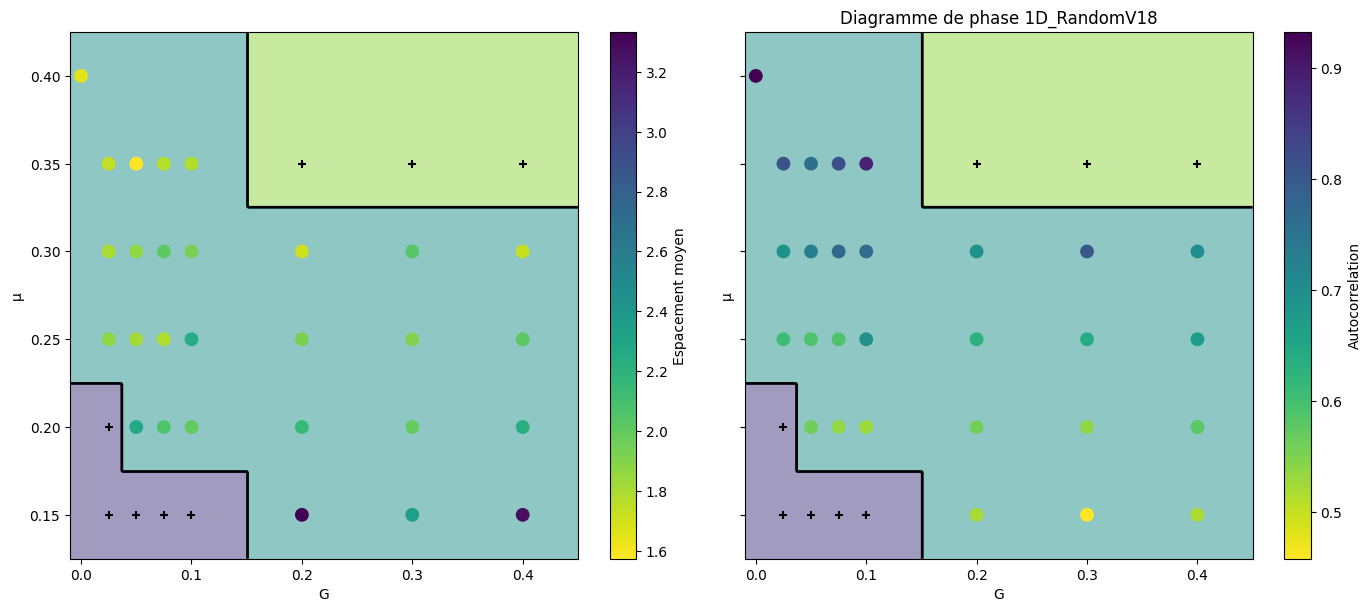

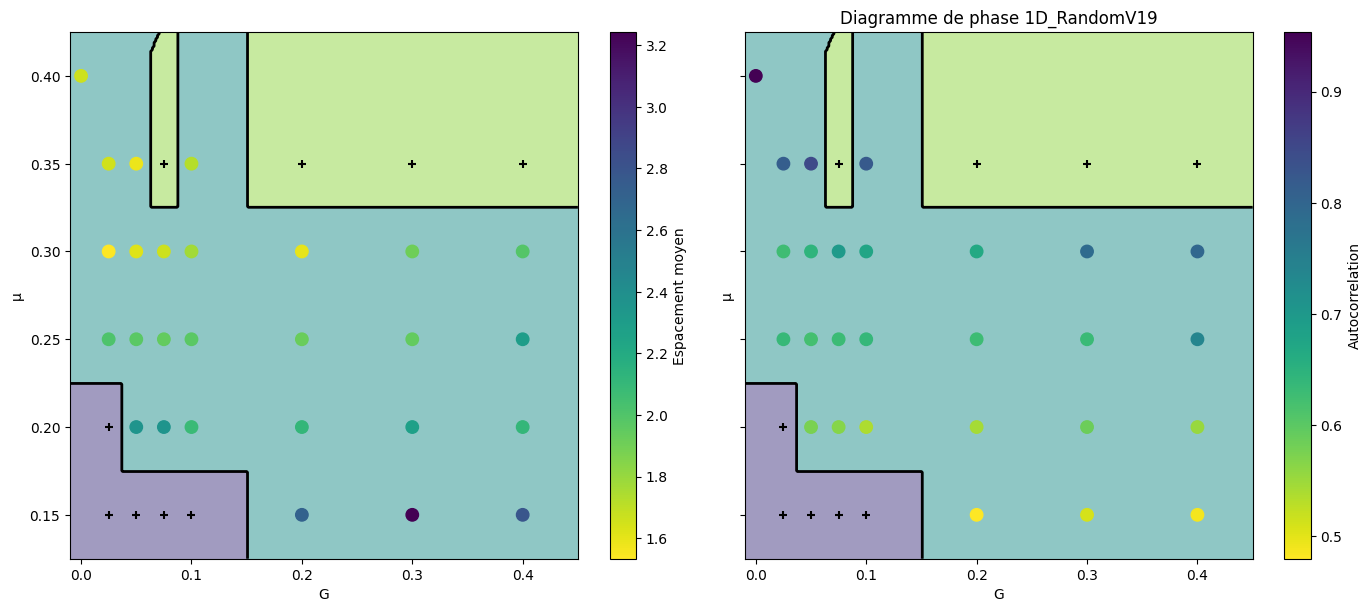

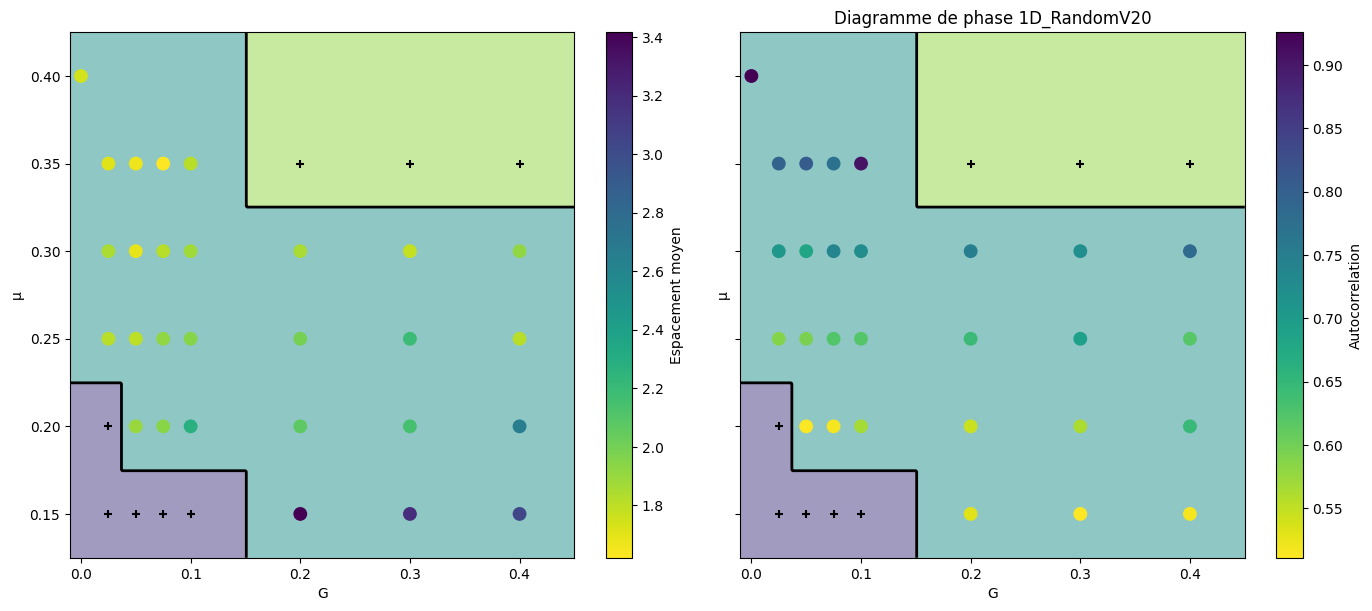

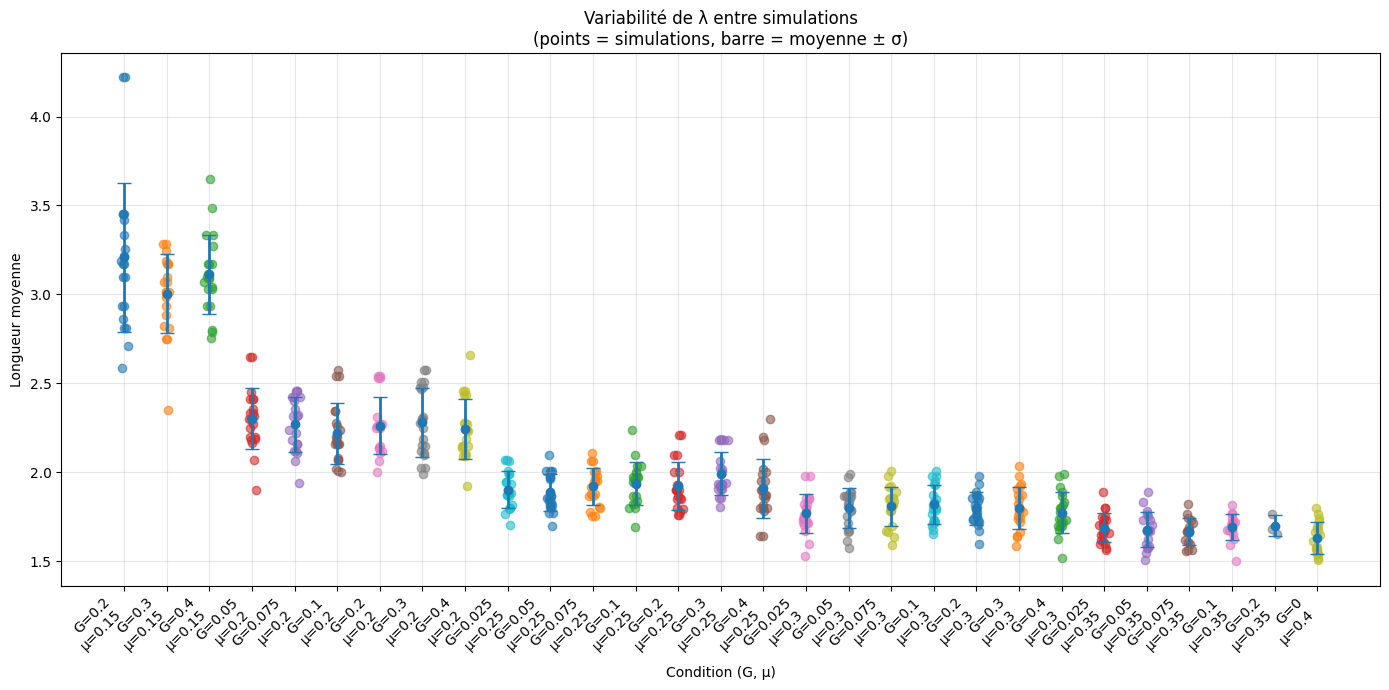

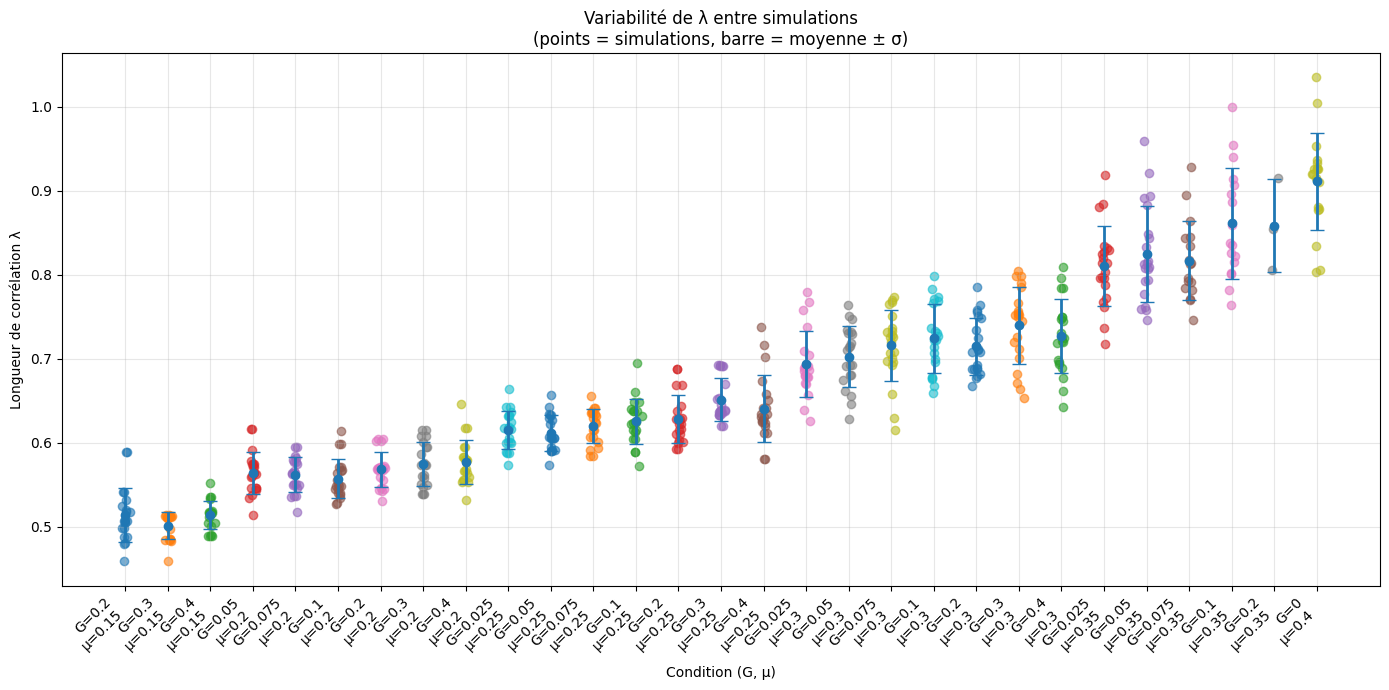

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Lecture de toutes les feuilles du ficher
excel_file = "./1D_RandomV1/Simu1D.xlsx"

sheets = pd.read_excel(
    excel_file,
    sheet_name=None
)


# Stockage des λ pour le graphe récapitulatif
all_pattern_data = []


# Une figure par feuille
for sheet_name, df in sheets.items():

        

    G = df["Column4"].values
    mu = df["Column3"].values
    lam1 = df["Column7"].values
    epai = df["Column9"].values
    cond = df["Column10"].values

    phase = np.zeros(len(df))

    phase[cond == "Mort"] = 0
    phase[cond == "Patterns"] = 1
    phase[cond == "Prolifération"] = 2


    mask_pattern = cond == "Patterns"

    for g_val, mu_val, lambda_val1, lambda_val2 in zip(
        G[mask_pattern],
        mu[mask_pattern],
        lam1[mask_pattern],
        epai[mask_pattern]
    ):
        all_pattern_data.append({
            "Sheet": sheet_name,
            "G": g_val,
            "mu": mu_val,
            "lambda1": lambda_val1,
            "lambda2" : lambda_val2
        })


    gx = np.linspace(G.min()- 0.01, G.max() +0.05, 300)
    gy = np.linspace(mu.min() -0.025, mu.max() + 0.025, 300)

    GX, MU = np.meshgrid(gx, gy)

    phase_grid = griddata(
        (G, mu),
        phase,
        (GX, MU),
        method="nearest"
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14,6),
        sharex=True,
        sharey=True
    )



    ax1.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5,0.5,1.5,2.5],
        alpha=0.5
    )

    ax1.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors='k',
        linewidths=2
    )

    mask_pattern = cond == "Patterns"

    sc1 = ax1.scatter(
        G[mask_pattern],
        mu[mask_pattern],
        c=lam1[mask_pattern],
        s=80,
        cmap=Cmap,
        #edgecolors='k'
    )
    fig.colorbar(
        sc1,
        ax=ax1,
        label="Espacement moyen"
    )

    mask_mort = cond == "Mort" 
    ax1.scatter(
        G[mask_mort],
        mu[mask_mort],
        c='k',
        marker='+',
        s=30
    )

    mask_Prolif = cond == "Prolifération" 
    ax1.scatter(
        G[mask_Prolif],
        mu[mask_Prolif],
        c='k',
        marker='+',
        s=30
    )

    ax1.set_xlabel("G")
    ax1.set_ylabel("μ")

    #ax1.set_title("Diagramme de phase longeur moyenne")

    ax2.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5,0.5,1.5,2.5],
        alpha=0.5
    )
    ax2.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors='k',
        linewidths=2
    )
    mask_pattern = cond == "Patterns"

    sc = ax2.scatter(
        G[mask_pattern],
        mu[mask_pattern],
        c=epai[mask_pattern],
        s=80,
        cmap=Cmap,
        #edgecolors='k'
    )

    fig.colorbar(
        sc,
        ax=ax2,
        label="Autocorrelation"
    )

    mask_mort = cond == "Mort" 
    ax2.scatter(
        G[mask_mort],
        mu[mask_mort],
        c='k',
        marker='+',
        s=30
    )

    mask_Prolif = cond == "Prolifération" 
    ax2.scatter(
        G[mask_Prolif],
        mu[mask_Prolif],
        c='k',
        marker='+',
        s=30
    )

    ax2.set_xlabel("G")
    ax2.set_ylabel("μ")

    #ax2.set_title("Diagramme de phase autocorrelation")

    plt.tight_layout()
    plt.title(
        f"Diagramme de phase {sheet_name}"
    )
plt.show()



# Graphe de dispersion de l'epaisseur et de l'espacement moyen entre les simulations
stats_df = pd.DataFrame(all_pattern_data)

if len(stats_df) > 0:

    summary1 = (
        stats_df
        .groupby([ "mu","G"])
        .agg(
            lambda_mean1=("lambda1", "mean"),
            lambda_std1=("lambda1", "std"),
            n=("lambda1", "count")
        )
        .reset_index()
    )
   

    plt.figure(figsize=(14,7))


    for i, row in summary1.iterrows():

        subset = stats_df[
            (stats_df["G"] == row["G"])
            &
            (stats_df["mu"] == row["mu"])
        ]

        xvals = np.random.normal(
            loc=i,
            scale=0.05,
            size=len(subset)
        )

        plt.scatter(
            xvals,
            subset["lambda1"],
            alpha=0.6
        )

    
    # Moyenne ± écart-type
    plt.errorbar(
        np.arange(len(summary1)),
        summary1["lambda_mean1"],
        yerr=summary1["lambda_std1"],
        fmt='o',
        capsize=5,
        linewidth=2
    )

    labels = [
        f"G={g:.3g}\nμ={m:.3g}"
        for g, m in zip(
            summary1["G"],
            summary1["mu"]
        )
    ]

    plt.xticks(
        np.arange(len(summary1)),
        labels,
        rotation=45,
        ha="right",
        
    )

    plt.ylabel("Longueur moyenne")
    plt.xlabel("Condition (G, μ)")
    plt.title(
        "Variabilité de λ entre simulations\n"
        "(points = simulations, barre = moyenne ± σ)"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,7))

    
    # Points individuels (une valeur par feuille)
    summary2 = (
        stats_df
        .groupby([ "mu","G"])
        .agg(
            lambda_mean2=("lambda2", "mean"),
            lambda_std2=("lambda2", "std"),
            n=("lambda2", "count")
        )
        .reset_index()
    )

    for i, row in summary2.iterrows():

        subset = stats_df[
            (stats_df["G"] == row["G"])
            &
            (stats_df["mu"] == row["mu"])
        ]

        xvals = np.random.normal(
            loc=i,
            scale=0.05,
            size=len(subset)
        )

        plt.scatter(
            xvals,
            subset["lambda2"],
            alpha=0.6
        )

    
    # Moyenne ± écart-type
    plt.errorbar(
        np.arange(len(summary2)),
        summary2["lambda_mean2"],
        yerr=summary2["lambda_std2"],
        fmt='o',
        capsize=5,
        linewidth=2
    )

    labels = [
        f"G={g:.3g}\nμ={m:.3g}"
        for g, m in zip(
            summary2["G"],
            summary2["mu"]
        )
    ]

    plt.xticks(
        np.arange(len(summary2)),
        labels,
        rotation=45,
        ha="right",
        
    )

    plt.ylabel("Longueur de corrélation λ")
    plt.xlabel("Condition (G, μ)")
    plt.title(
        "Variabilité de λ entre simulations\n"
        "(points = simulations, barre = moyenne ± σ)"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Un diagramme de phase moyen est ensuite construit à partir des 20 simulations indépendantes.

La classification des régimes est réalisée selon la règle suivante :

Une condition est classée dans le régime Pattern sur le diagramme de phase final uniquement si elle est identifiée comme Pattern dans l'ensemble des simulations indépendantes.

La taille des points représente la variabilité entre les simulations, mesurée à partir de l'écart-type.

Ainsi :

un petit point correspond à une faible variabilité ;
un gros point correspond à une forte variabilité entre les simulations.

Cette représentation permet donc de visualiser simultanément le comportement moyen du système et sa sensibilité aux conditions initiales.

C:\Users\lisab\AppData\Local\Temp\ipykernel_15064\2619841549.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('viridis')


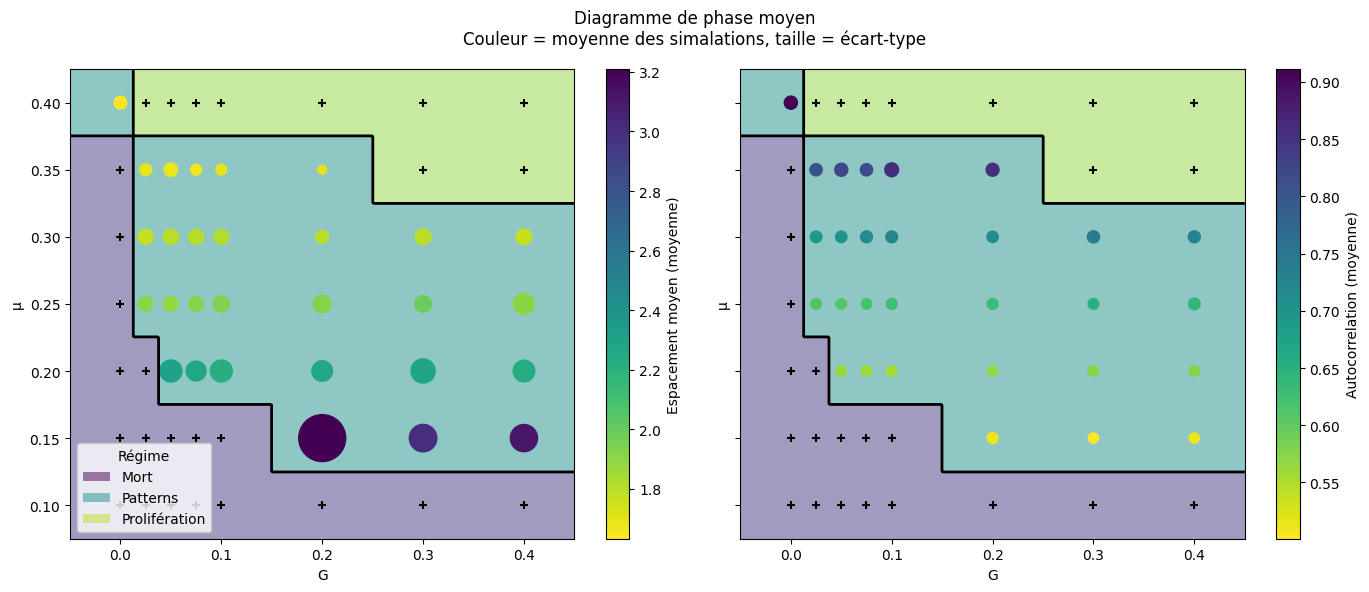

In [ ]:
all_data = []

for sheet_name, df in sheets.items():

    for _, row in df.iterrows():

        all_data.append({
            
            "G": row["Column4"],
            "mu": row["Column3"],
            "lambda1": row["Column7"],
            "lambda2": row["Column9"],
            "cond": row["Column10"]
        })

all_df = pd.DataFrame(all_data)

# Statistiques des points Patterns
pattern_df = all_df[
    all_df["cond"] == "Patterns"
]

summary = (
    pattern_df
    .groupby(["G", "mu"])
    .agg(
        lambda1_mean=("lambda1", "mean"),
        lambda1_std=("lambda1", "std"),
        lambda2_mean=("lambda2", "mean"),
        lambda2_std=("lambda2", "std")
    )
    .reset_index()
)

summary = summary.fillna(0)

# Phase dominante
# Pattern prioritaire
phase_data = []

for (g, mu), sub in all_df.groupby(["G", "mu"]):

    conds = set(sub["cond"])

    if "Patterns" in conds:
        phase = 1
    elif "Prolifération" in conds:
        phase = 2
    else:
        phase = 0

    phase_data.append({
        "G": g,
        "mu": mu,
        "phase": phase
    })

phase_df = pd.DataFrame(phase_data)

gx = np.linspace(
    phase_df["G"].min()-0.05,
    phase_df["G"].max()+0.05,
    300
)

gy = np.linspace(
    phase_df["mu"].min()-0.025,
    phase_df["mu"].max()+0.025,
    300
)

GX, MU = np.meshgrid(gx, gy)

phase_grid = griddata(
    (phase_df["G"], phase_df["mu"]),
    phase_df["phase"],
    (GX, MU),
    method="nearest"
)

# Taille des marqueurs ( à ajuster pour un but esthétique du graphe)
size_scale = 5000
size_gamma = 1.7

sizes1 = 1+ size_scale * (summary["lambda1_std"] ** size_gamma)
sizes2 = 50+ size_scale * (summary["lambda2_std"] ** size_gamma)


# Figure
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,6),
    sharex=True,
    sharey=True
)

for ax in [ax1, ax2]:

    ax.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5,0.5,1.5,2.5],
        alpha=0.5
    )

    ax.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors="k",
        linewidths=2
    )

mort = phase_df["phase"] == 0
prolif = phase_df["phase"] == 2

for ax in [ax1, ax2]:

    ax.scatter(
        phase_df.loc[mort, "G"],
        phase_df.loc[mort, "mu"],
        marker="+",
        c="k",
        s=30
    )

    ax.scatter(
        phase_df.loc[prolif, "G"],
        phase_df.loc[prolif, "mu"],
        marker="+",
        c="k",
        s=30
    )

orig_map=plt.cm.get_cmap('viridis')

# reversing the original colormap using reversed() function
Cmap = orig_map.reversed()
sc1 = ax1.scatter(
    summary["G"],
    summary["mu"],
    c=summary["lambda1_mean"],
    s=sizes1,
    cmap=Cmap,
    #edgecolors="k"
)

fig.colorbar(
    sc1,
    ax=ax1,
    label="Espacement moyen (moyenne)"
)

from matplotlib.patches import Patch
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=2)

legend_elements = [
    Patch(
        facecolor=cmap(norm(0)), alpha=0.5,
        label="Mort"
    ),
    Patch(
        facecolor=cmap(norm(1)), alpha=0.5,
        label="Patterns"
    ),
    Patch(
        facecolor=cmap(norm(1.8)), alpha=0.5,
        label="Prolifération"
    )
]

ax1.legend(
handles=legend_elements,
title="Régime",
loc="lower left")

ax1.set_xlabel("G")
ax1.set_ylabel("μ")


sc2 = ax2.scatter(
    summary["G"],
    summary["mu"],
    c=summary["lambda2_mean"],
    s=sizes2,
    cmap=Cmap,
    #edgecolors="k"
)

fig.colorbar(
    sc2,
    ax=ax2,
    label="Autocorrelation (moyenne)"
)

ax2.set_xlabel("G")
ax2.set_ylabel("μ")

plt.suptitle(
    "Diagramme de phase moyen\n"
    "Couleur = moyenne des simalations, taille = écart-type"
)

plt.tight_layout()
plt.show()

Cette cellule permet de visualiser l'évolution de l'autocorrélation lorsque le paramètre μ augmente pour une valeur de G fixée.

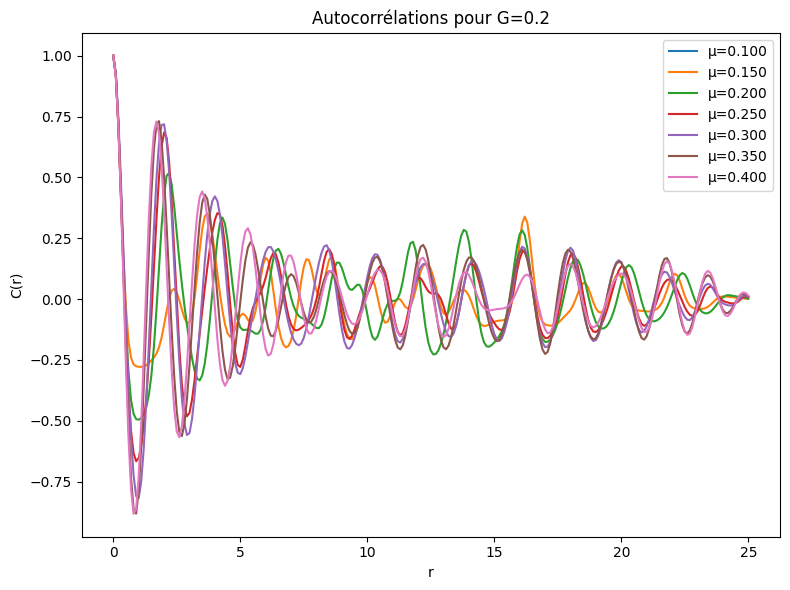

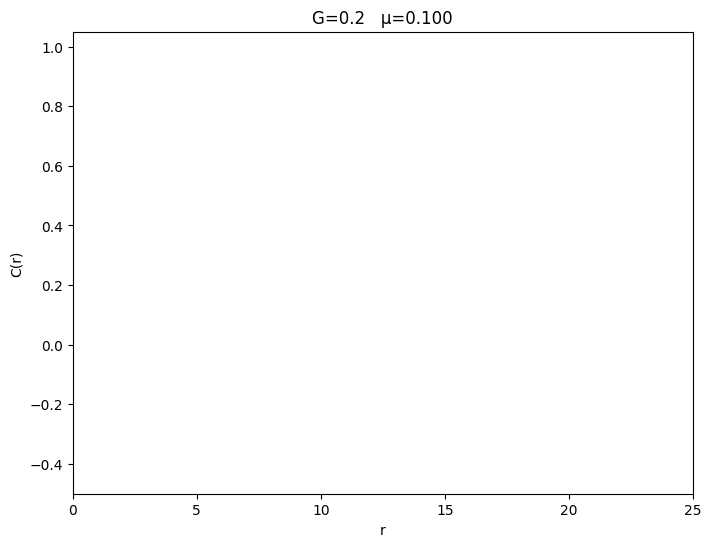

In [14]:
G_target = 0.2

subset = [
    res for res in results
    if np.isclose(res["G"], G_target)
]

subset.sort(key=lambda x: x["mu"])

plt.figure(figsize=(8,6))

for res in subset:

    plt.plot(
        res["r"],
        res["corr"],
        label=f"μ={res['mu']:.3f}"
    )

plt.xlabel("r")
plt.ylabel("C(r)")
plt.title(f"Autocorrélations pour G={G_target}")
plt.legend()

plt.tight_layout()
plt.show()

from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots(figsize=(8,6))

line, = ax.plot([], [])

ax.set_xlim(
    0,
    max(np.max(res["r"]) for res in subset)
)

ax.set_ylim(-0.5, 1.05)

ax.set_xlabel("r")
ax.set_ylabel("C(r)")
def update(frame):

    res = subset[frame]

    line.set_data(
        res["r"],
        res["corr"]
    )

    ax.set_title(
        f"G={G_target}   μ={res['mu']:.3f}"
    )

    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=len(subset),
    interval=800
)

ani.save(
    f"autocorr_G_{G_target}.gif",
    writer="pillow"
)

Ce code essaie d'étudier l'évolution de l'espacement moyen et de l'ecart type de l'espacement moyen en fonction du temps, et cela pour plusieurs G

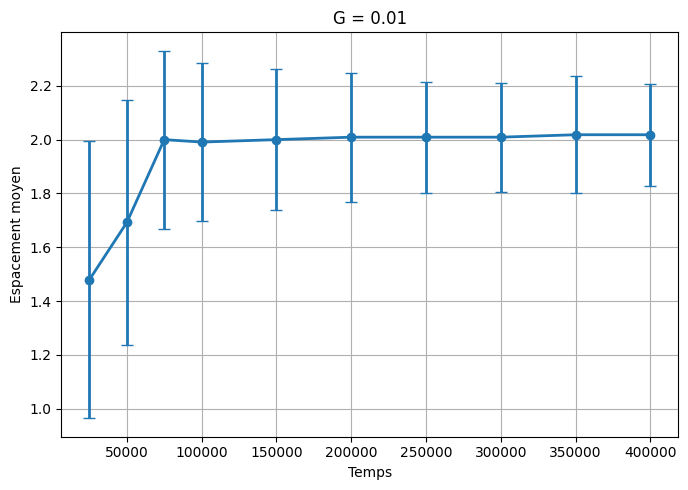

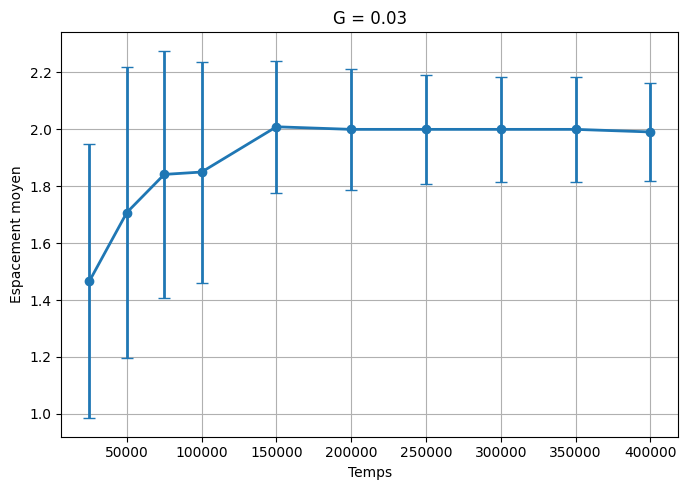

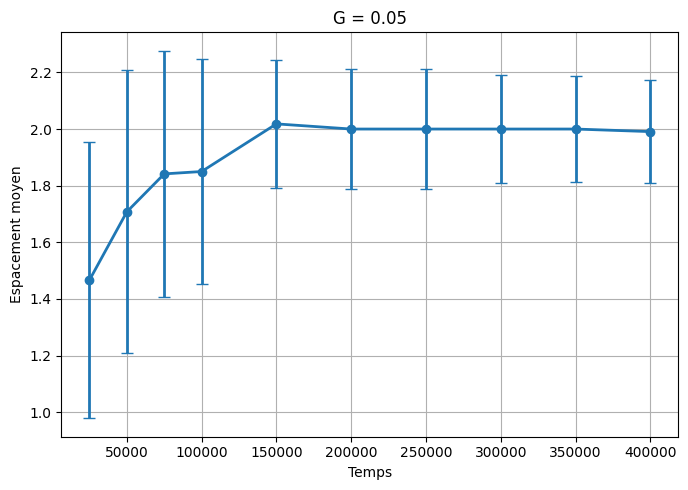

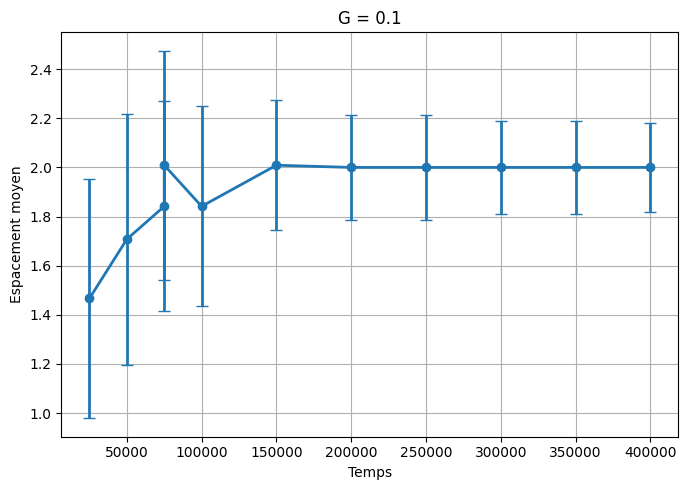

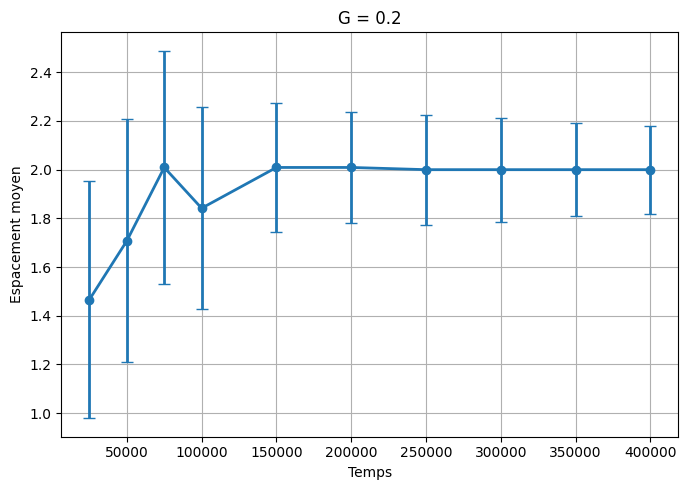

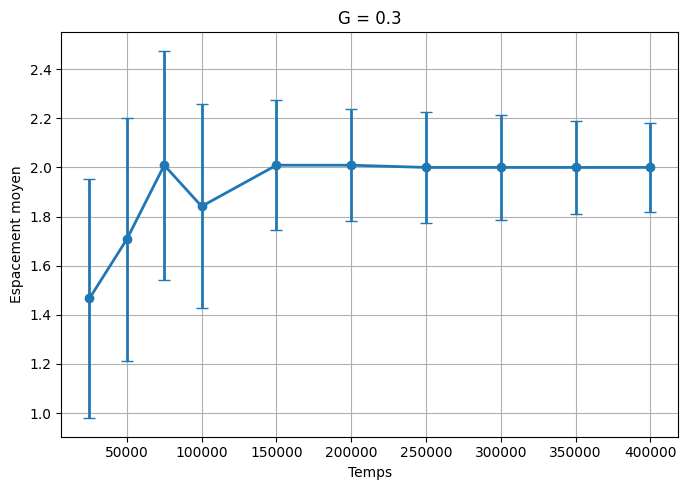

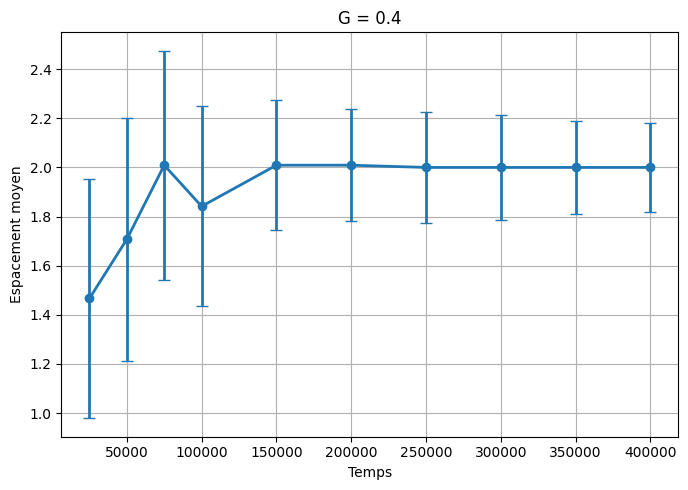

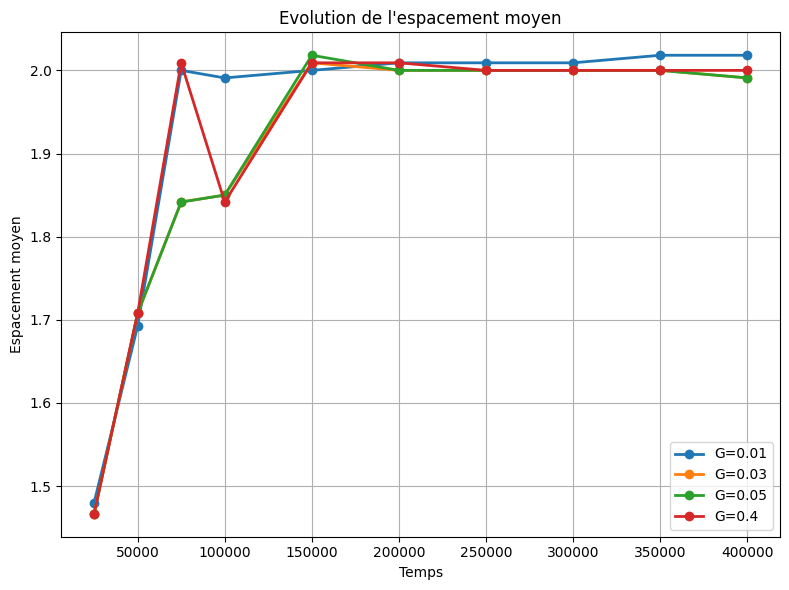

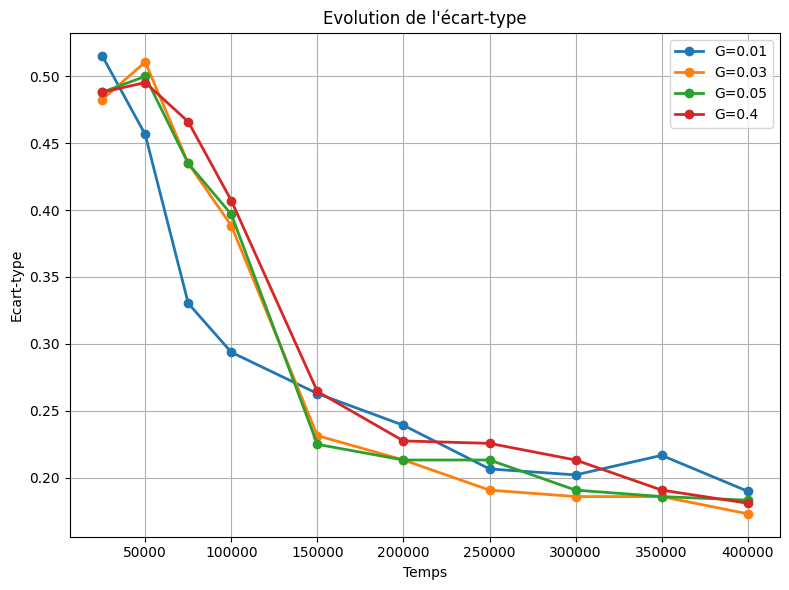

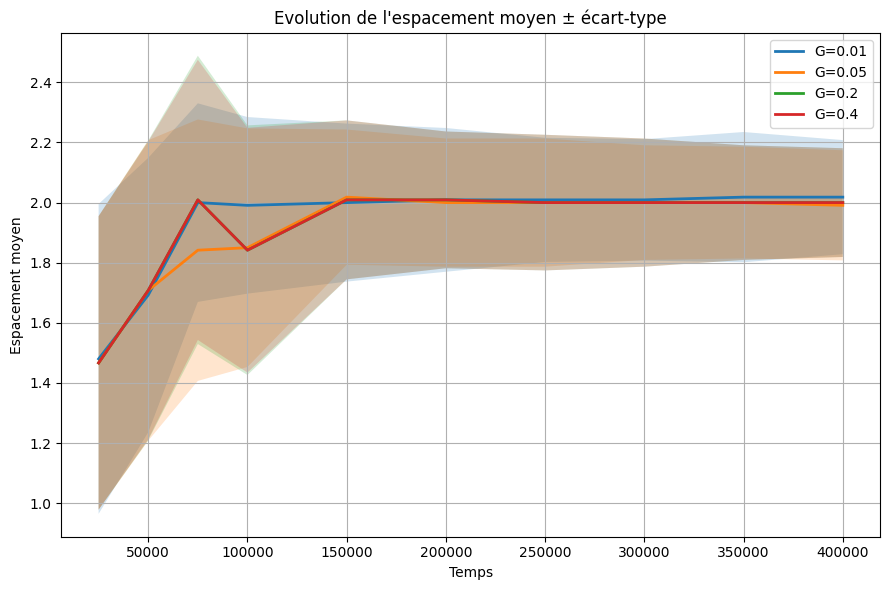

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Lecture du fichier Excel
# =====================================================

df = pd.read_excel("./TuneG_1D/Simu.xlsx")

# Colonnes
t = df["Column1"]
G = df["Column4"]
esp_moy = df["Column7"]
esp_std = df["Column8"]

# Liste des valeurs de G
liste_G = sorted(df["Column4"].unique())

# =====================================================
# 1) Un graphique pour chaque G
# =====================================================

for g in liste_G:

    data = df[df["Column4"] == g].sort_values("Column1")

    plt.figure(figsize=(7,5))

    plt.errorbar(
        data["Column1"],
        data["Column7"],
        yerr=data["Column8"],
        fmt='o-',
        capsize=4,
        linewidth=2,
        markersize=6
    )

    plt.title(f"G = {g}")
    plt.xlabel("Temps")
    plt.ylabel("Espacement moyen")
    plt.grid(True)

    plt.tight_layout()

# =====================================================
# 2) Comparaison des espacement moyens
# =====================================================

plt.figure(figsize=(8,6))

for g in liste_G:
    if g != 0.3 and g !=0.1  and g !=0.2 :
        data = df[df["Column4"] == g].sort_values("Column1")

        plt.plot(
            data["Column1"],
            data["Column7"],
            marker='o',
            linewidth=2,
            label=f"G={g}"
        )

plt.xlabel("Temps")
plt.ylabel("Espacement moyen")
plt.title("Evolution de l'espacement moyen")
plt.legend()
plt.grid(True)
plt.tight_layout()

# =====================================================
# 3) Comparaison des écarts-types
# =====================================================

plt.figure(figsize=(8,6))

for g in liste_G:

    if g != 0.3 and g !=0.1 and g !=0.2 :
        data = df[df["Column4"] == g].sort_values("Column1")

        plt.plot(
            data["Column1"],
            data["Column8"],
            marker='o',
            linewidth=2,
            label=f"G={g}"
        )

plt.xlabel("Temps")
plt.ylabel("Ecart-type")
plt.title("Evolution de l'écart-type")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(9,6))

for g in liste_G:

    if g != 0.03 and g !=0.1 and g !=0.3 :
        data = df[df["Column4"] == g].sort_values("Column1")

        t = data["Column1"]
        m = data["Column7"]
        s = data["Column8"]

        plt.plot(t, m, linewidth=2, label=f"G={g}")
        plt.fill_between(t, m-s, m+s, alpha=0.2)

plt.xlabel("Temps")
plt.ylabel("Espacement moyen")
plt.title("Evolution de l'espacement moyen ± écart-type")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.show()